In [3]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
 print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')

Saving data_preprocessed.xlsx to data_preprocessed.xlsx
User uploaded file "data_preprocessed.xlsx" with length 3946202 bytes


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import nltk
from nltk.tokenize import word_tokenize
from nltk.util import ngrams

In [7]:
filename = "data_preprocessed.xlsx"
df = pd.read_excel(filename)
display(df.head())

,source,text,topic,keyword,post_url,label
0,threads,m bựa à,the_thao,Bóng đá,https://www.threads.com/@lismine.0/post/DWHLZw...,2
1,threads,mấy ảnh xạo á bây,the_thao,Thể thao,https://www.threads.com/@vomanhtoan76/post/DBX...,2
2,threads,cái này là bè nhóm chứ không phải bạn không ph...,the_thao,Thể thao,https://www.threads.com/@_gudoldays_/post/DYMo...,2
3,threads,ôi xời toàn bọn sĩ diện hão bạn kệ mịe bno đi,the_thao,Thể thao,https://www.threads.com/@_gudoldays_/post/DYMo...,2
4,threads,vấn đề thể lực thôi hài ỉa mấy con vợ tâm lý c...,the_thao,Thể thao,https://www.threads.com/@owl.1393541/post/DTr_...,2


# I. Phân tích đơn biến

### a. Cột label

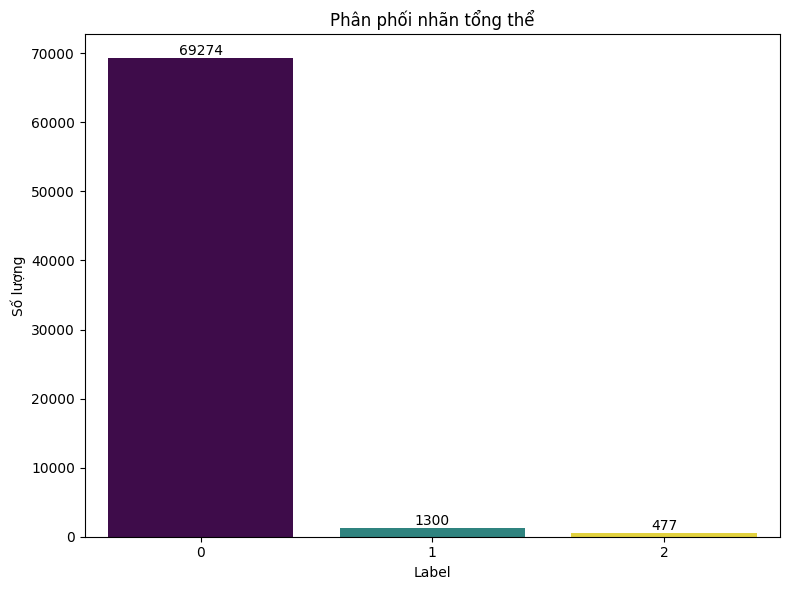

In [9]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='label', hue='label', palette='viridis', legend=False)
plt.title('Phân phối nhãn tổng thể')
plt.xlabel('Label')
plt.ylabel('Số lượng')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')

plt.tight_layout()
plt.show()

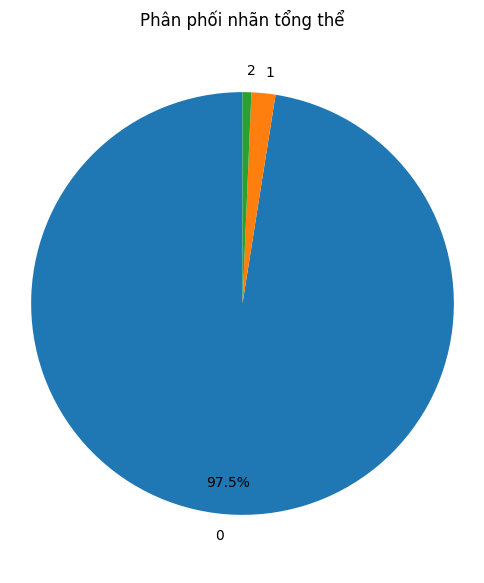

In [10]:
label_counts = df['label'].value_counts()

plt.figure(figsize=(6, 7))

def autopct_format(pct):
    return ('%.1f%%' % pct) if pct > 2 else ''

plt.pie(label_counts, labels=label_counts.index, autopct=autopct_format, startangle=90, pctdistance=0.85)
plt.title('Phân phối nhãn tổng thể')
plt.axis('equal')
plt.show()

### b. Cột source

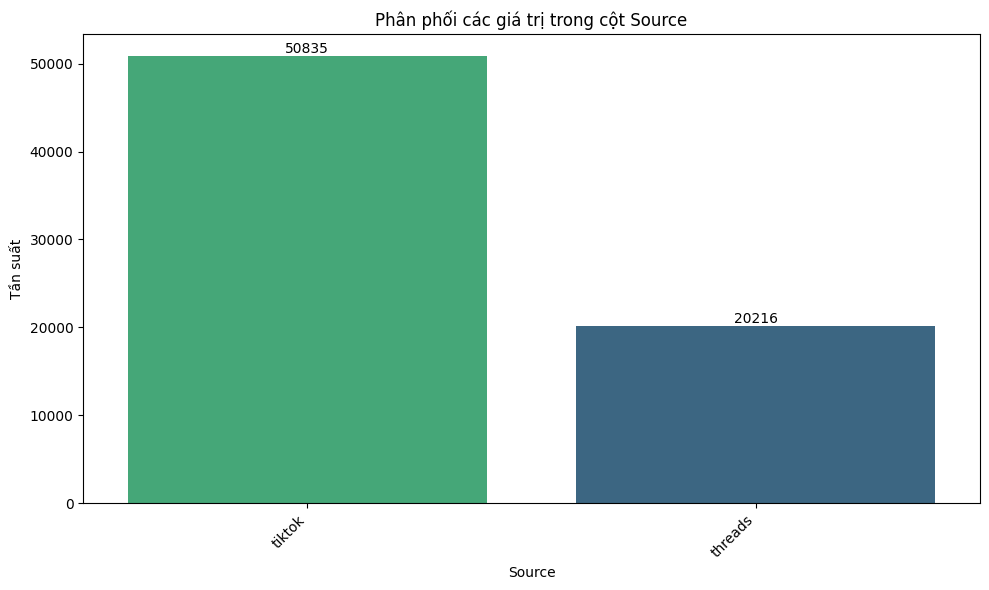

In [11]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='source', hue='source', palette='viridis', legend=False, order=df['source'].value_counts().index)
plt.title('Phân phối các giá trị trong cột Source')
plt.xlabel('Source')
plt.ylabel('Tần suất')
plt.xticks(rotation=45, ha='right')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')

plt.tight_layout()
plt.show()

### c. Cột topic

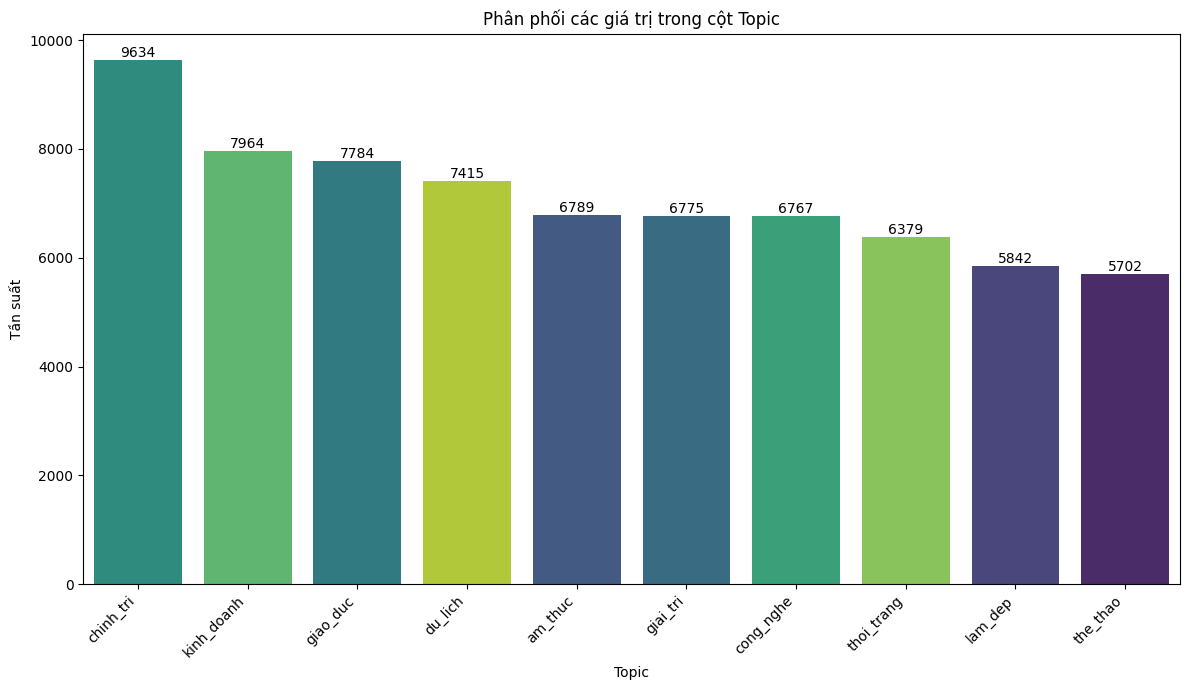

In [12]:
plt.figure(figsize=(12, 7))
ax = sns.countplot(data=df, x='topic', hue='topic', palette='viridis', legend=False, order=df['topic'].value_counts().index)
plt.title('Phân phối các giá trị trong cột Topic')
plt.xlabel('Topic')
plt.ylabel('Tần suất')
plt.xticks(rotation=45, ha='right')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')

plt.tight_layout()
plt.show()

### d. Cột text

- Độ dài câu

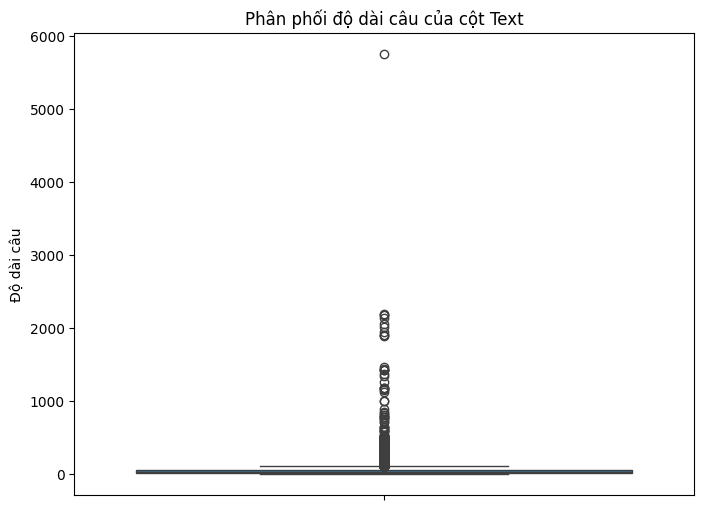

In [13]:
df['text'] = df['text'].astype(str)
df['text_length'] = df['text'].apply(len)

plt.figure(figsize=(8, 6))
sns.boxplot(y=df['text_length'])
plt.title('Phân phối độ dài câu của cột Text')
plt.ylabel('Độ dài câu')
plt.show()

- Tần suất từ

In [14]:
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

def get_ngrams(text, n_val):
    tokens = word_tokenize(text)
    tokens = [token for token in tokens if token.strip()]
    if not tokens:
        return []
    return list(ngrams(tokens, n_val))

def plot_top_ngrams(ngrams_list, title, ax, top_n=20):
    ngram_counts = Counter([' '.join(ngram) for ngram in ngrams_list])
    top_ngrams = ngram_counts.most_common(top_n)

    df_ngrams = pd.DataFrame(top_ngrams, columns=['ngram', 'count'])

    sns.barplot(x='count', y='ngram', data=df_ngrams, ax=ax, palette='viridis', hue='ngram', legend=False)
    ax.set_title(title)
    ax.set_xlabel('Tần suất')
    ax.set_ylabel('N-gram')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


/tmp/ipykernel_1265/58666295.py:14: UserWarning: Glyph 4448 (\N{HANGUL JUNGSEONG FILLER}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4448 (\N{HANGUL JUNGSEONG FILLER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


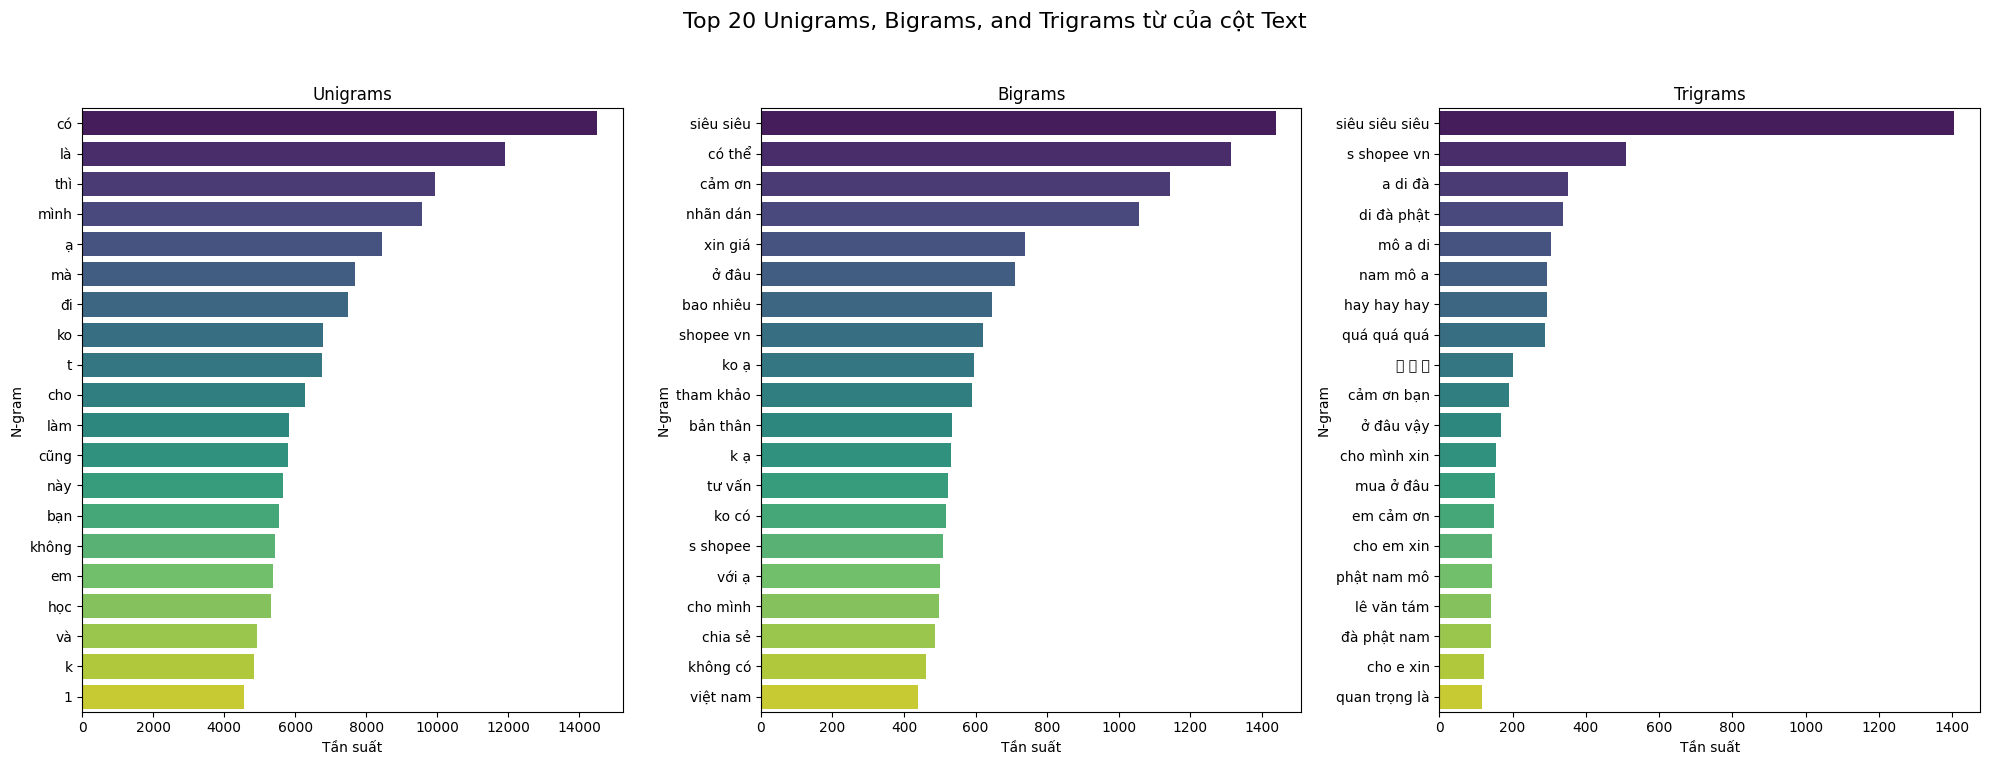

In [15]:
combined_text_all = ' '.join(df['text'].astype(str))

unigrams_all = get_ngrams(combined_text_all, 1)
bigrams_all = get_ngrams(combined_text_all, 2)
trigrams_all = get_ngrams(combined_text_all, 3)

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle('Top 20 Unigrams, Bigrams, and Trigrams từ của cột Text', fontsize=16)

plot_top_ngrams(unigrams_all, 'Unigrams', axes[0])
plot_top_ngrams(bigrams_all, 'Bigrams', axes[1])
plot_top_ngrams(trigrams_all, 'Trigrams', axes[2])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# II. Phân tích dữ liệu 2 biến

### a. Cột label và cột source

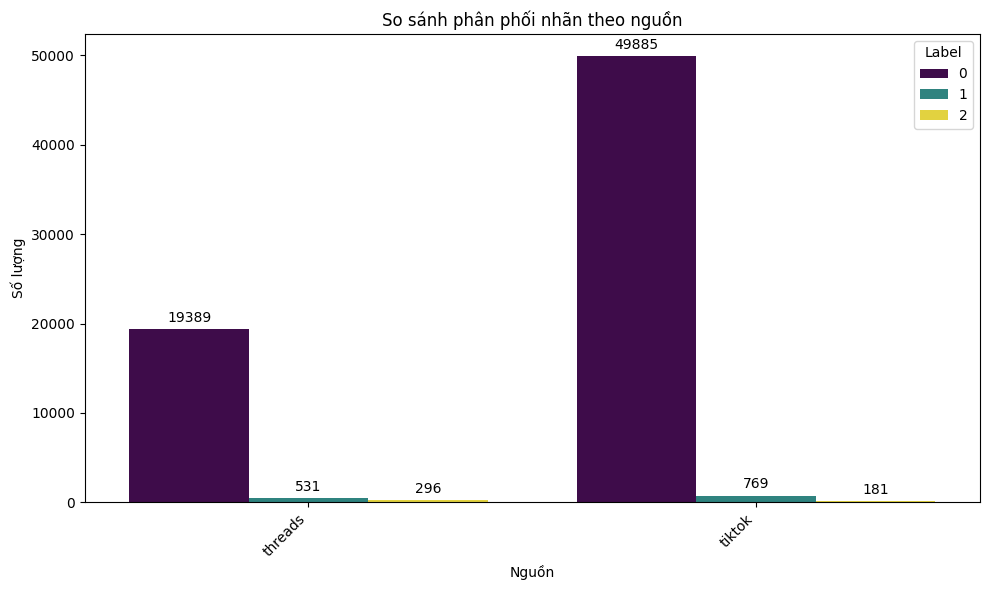

In [16]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='source', hue='label', palette='viridis')
plt.title('So sánh phân phối nhãn theo nguồn')
plt.xlabel('Nguồn')
plt.ylabel('Số lượng')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Label')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)

plt.tight_layout()
plt.show()

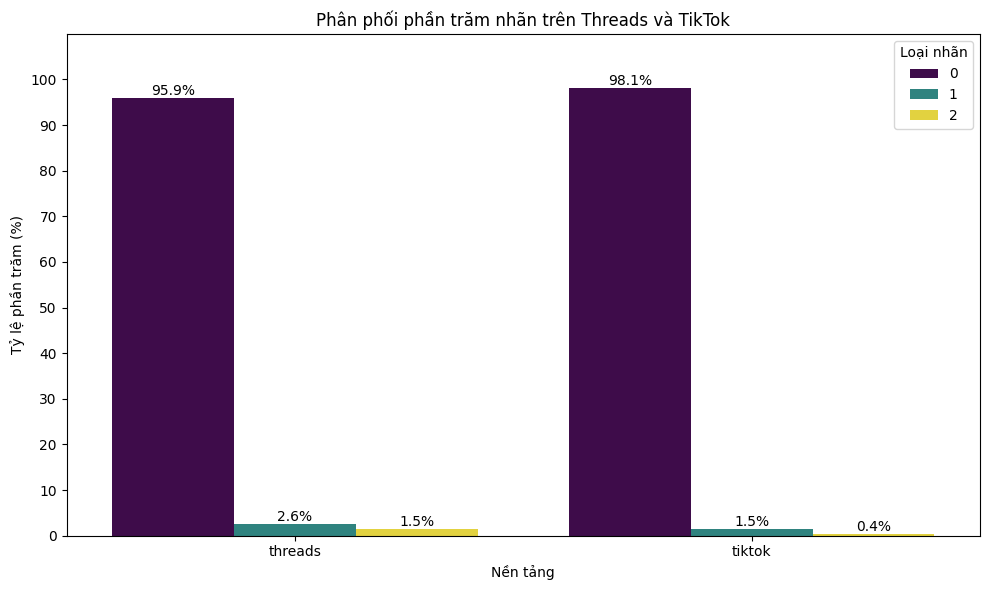

In [17]:
df_filtered = df[df['source'].isin(['threads', 'tiktok'])]

label_source_counts = df_filtered.groupby(['source', 'label']).size().unstack(fill_value=0)

label_source_percentages = label_source_counts.apply(lambda x: x / x.sum() * 100, axis=1)

df_plot = label_source_percentages.reset_index().melt(id_vars='source', var_name='label', value_name='percentage')

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_plot, x='source', y='percentage', hue='label', palette='viridis')

plt.title('Phân phối phần trăm nhãn trên Threads và TikTok')
plt.xlabel('Nền tảng')
plt.ylabel('Tỷ lệ phần trăm (%)')
plt.ylim(0, 110)
plt.yticks(range(0, 101, 10))
plt.legend(title='Loại nhãn')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge')

plt.tight_layout()
plt.show()

### b. Cột label và cột topic

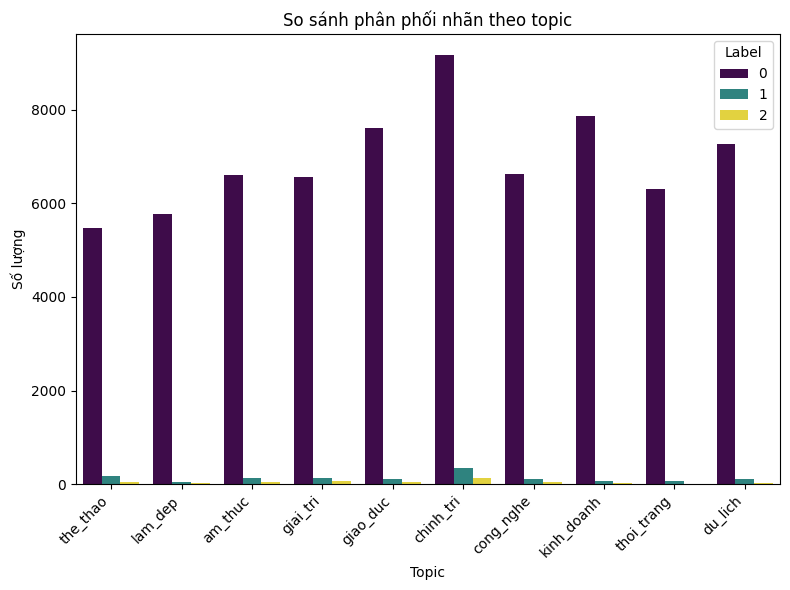

In [18]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='topic', hue='label', palette='viridis')
plt.title('So sánh phân phối nhãn theo topic')
plt.xlabel('Topic')
plt.ylabel('Số lượng')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Label')
plt.tight_layout()
plt.show()

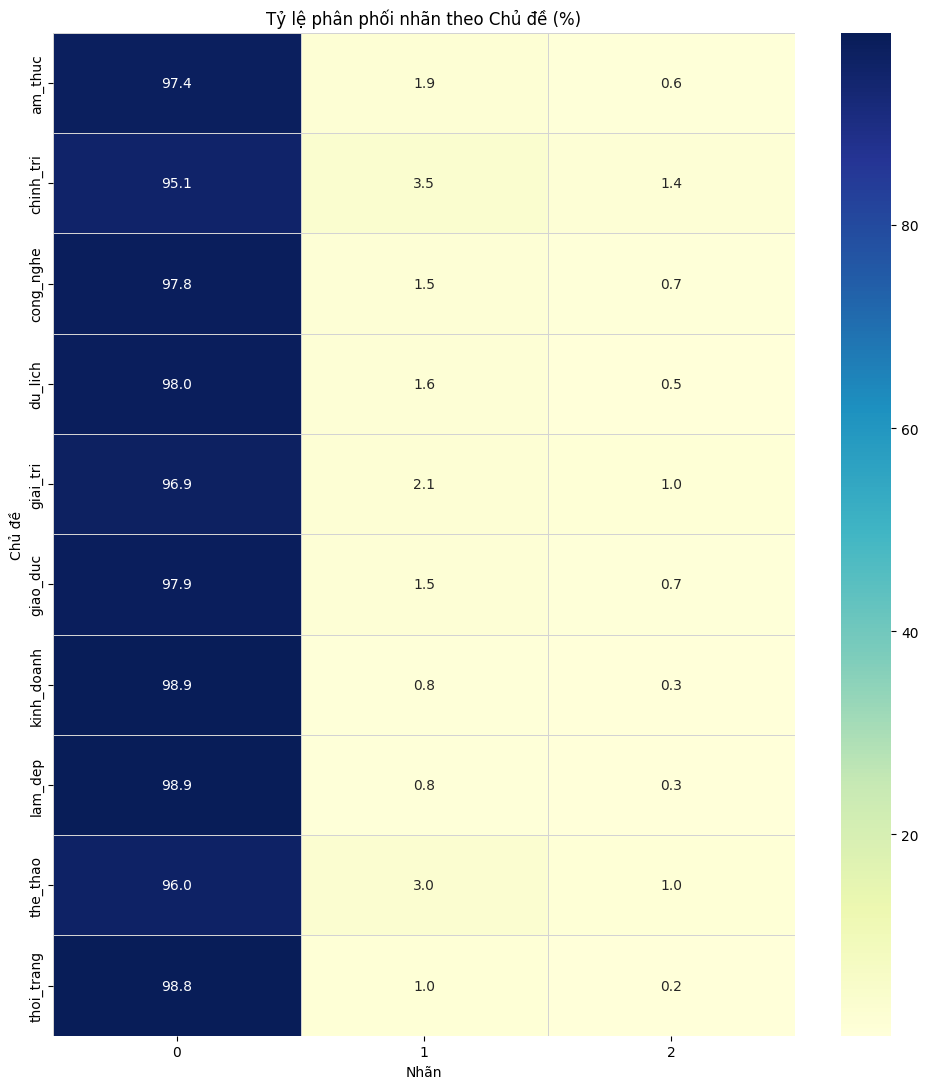

In [19]:
topic_label_counts = df.groupby(['topic', 'label']).size().unstack(fill_value=0)

# Chuẩn hóa dữ liệu để hiển thị tỷ lệ phần trăm theo từng hàng (topic)
# Mỗi hàng sẽ có tổng là 100%
topic_label_percentages = topic_label_counts.apply(lambda x: (x / x.sum()) * 100, axis=1)

plt.figure(figsize=(10, 11))
sns.heatmap(topic_label_percentages, annot=True, fmt='.1f', cmap='YlGnBu', linewidths=.5, linecolor='lightgray')
plt.title('Tỷ lệ phân phối nhãn theo Chủ đề (%)')
plt.xlabel('Nhãn')
plt.ylabel('Chủ đề')
plt.tight_layout()
plt.show()

### c. Cột text và cột label

- Cột label và N-gram


 N-grams của label: 0


/tmp/ipykernel_1265/4021403738.py:25: UserWarning: Glyph 4448 (\N{HANGUL JUNGSEONG FILLER}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4448 (\N{HANGUL JUNGSEONG FILLER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


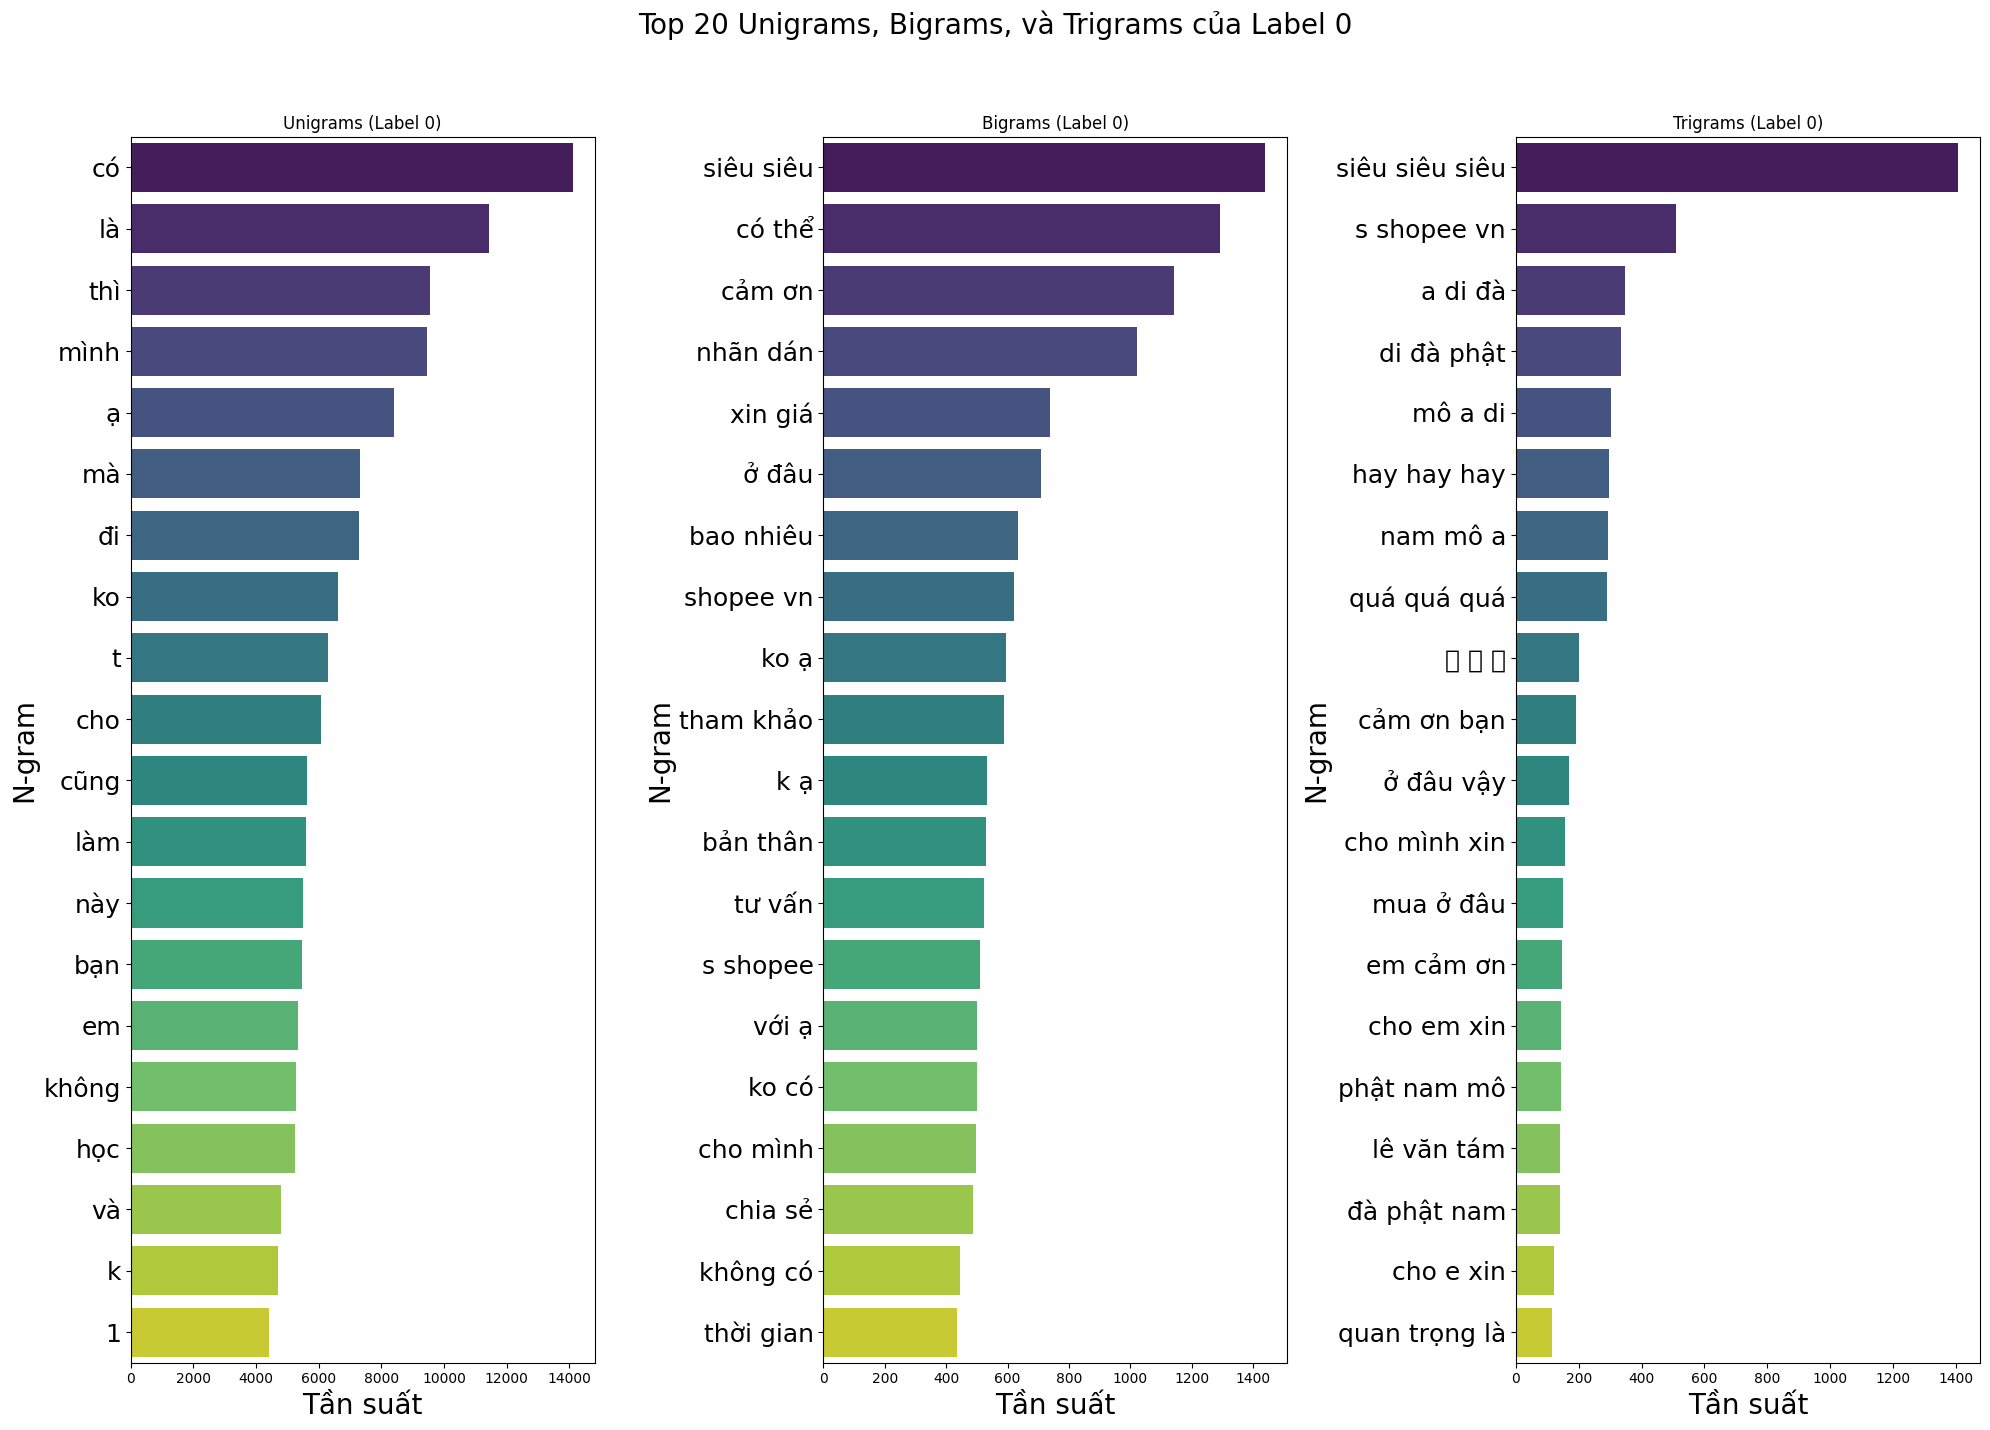


 N-grams của label: 1


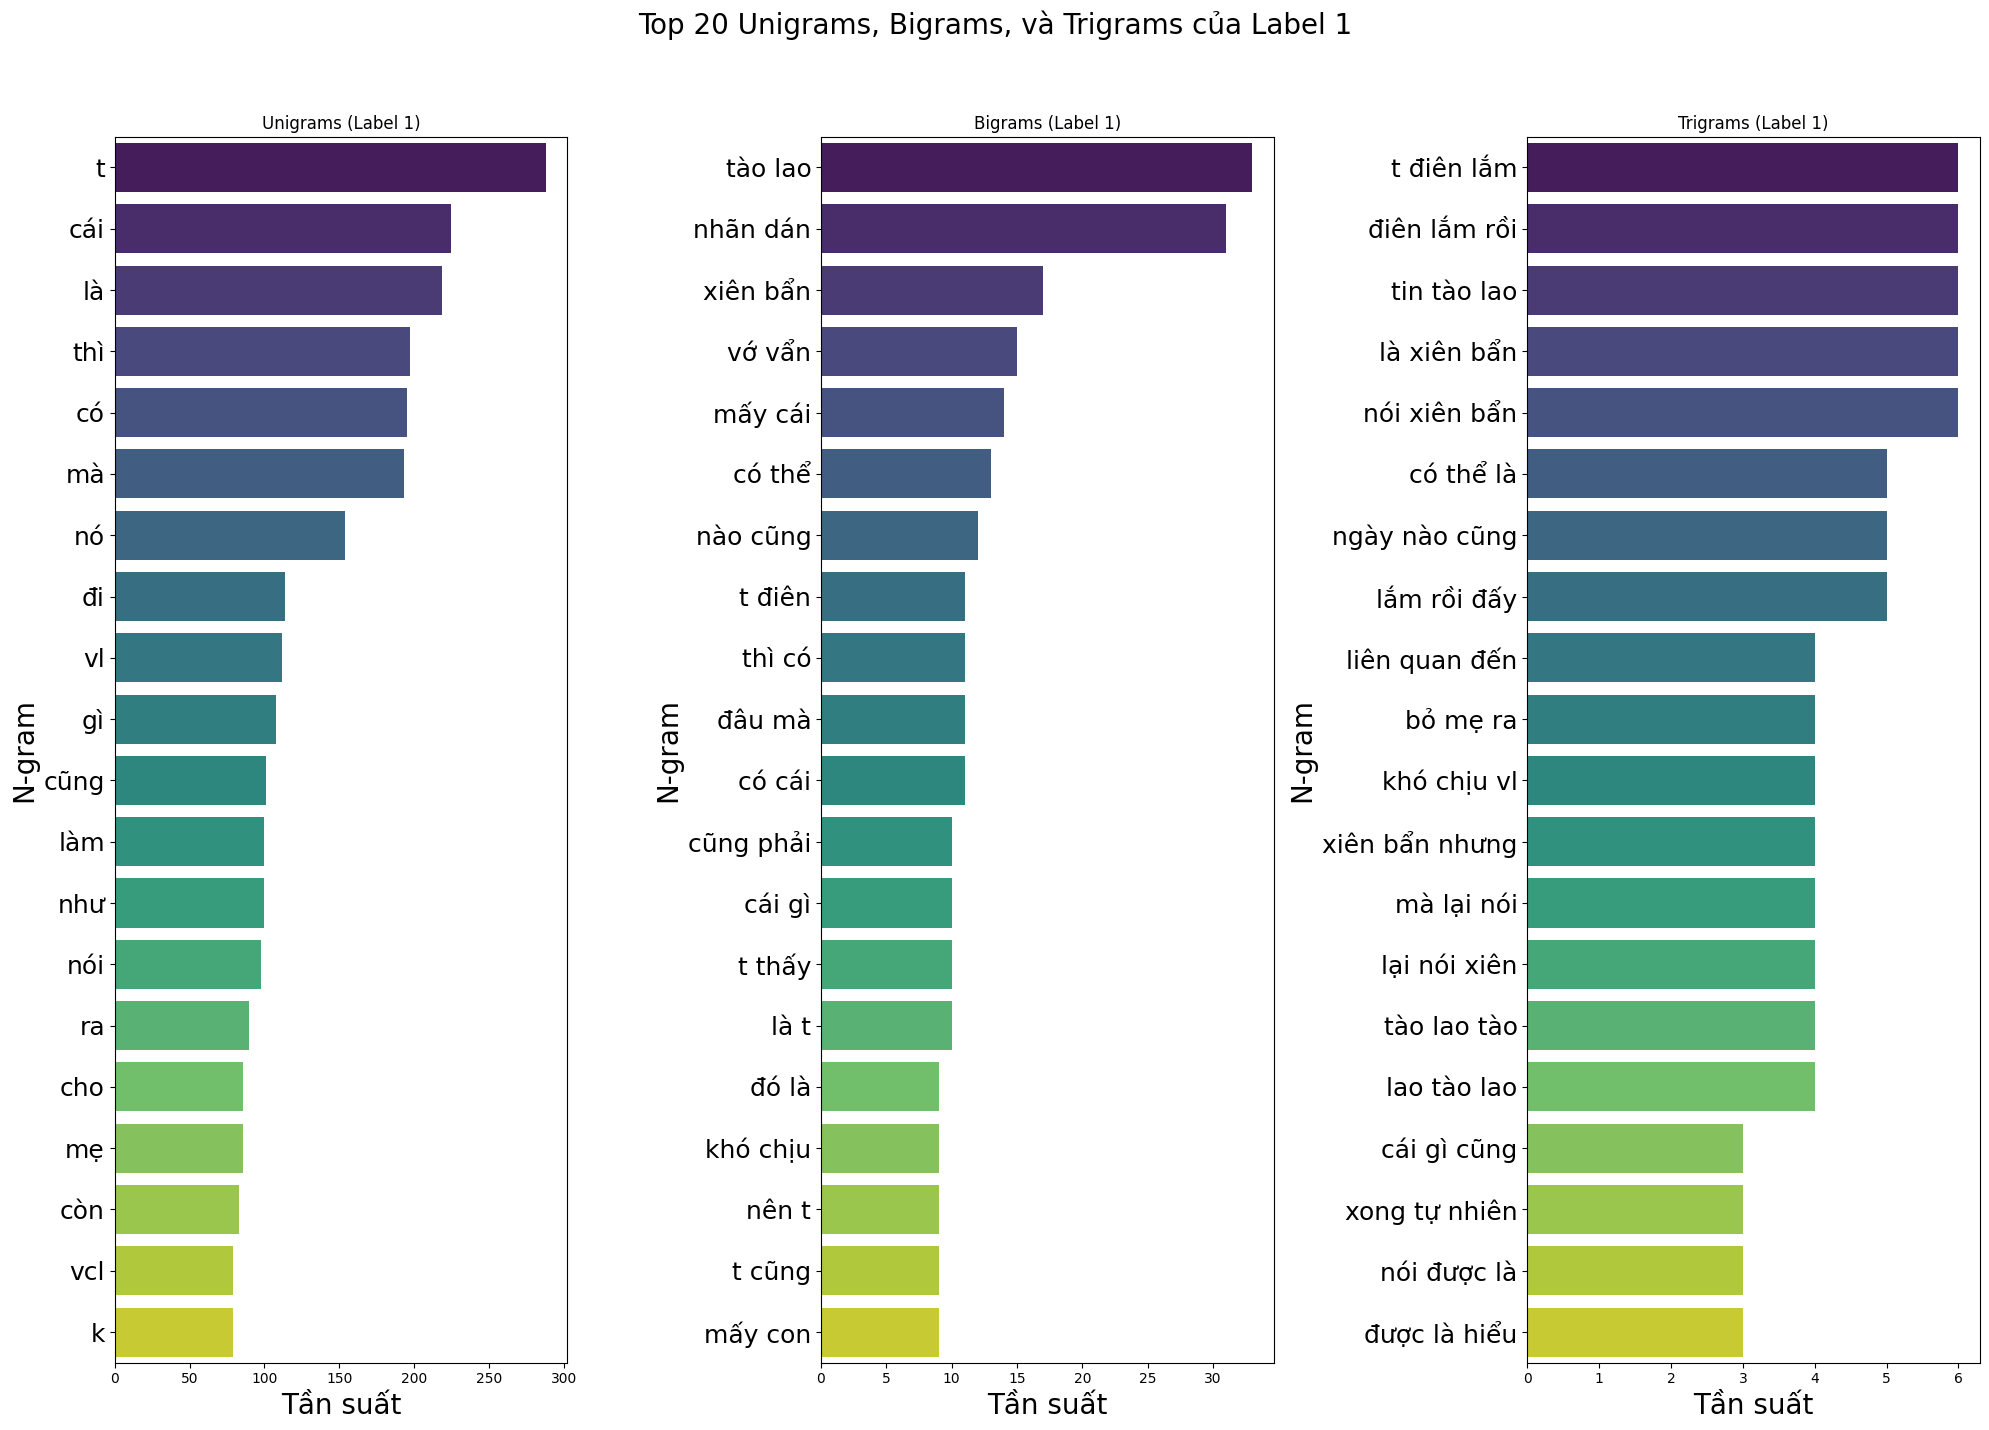


 N-grams của label: 2


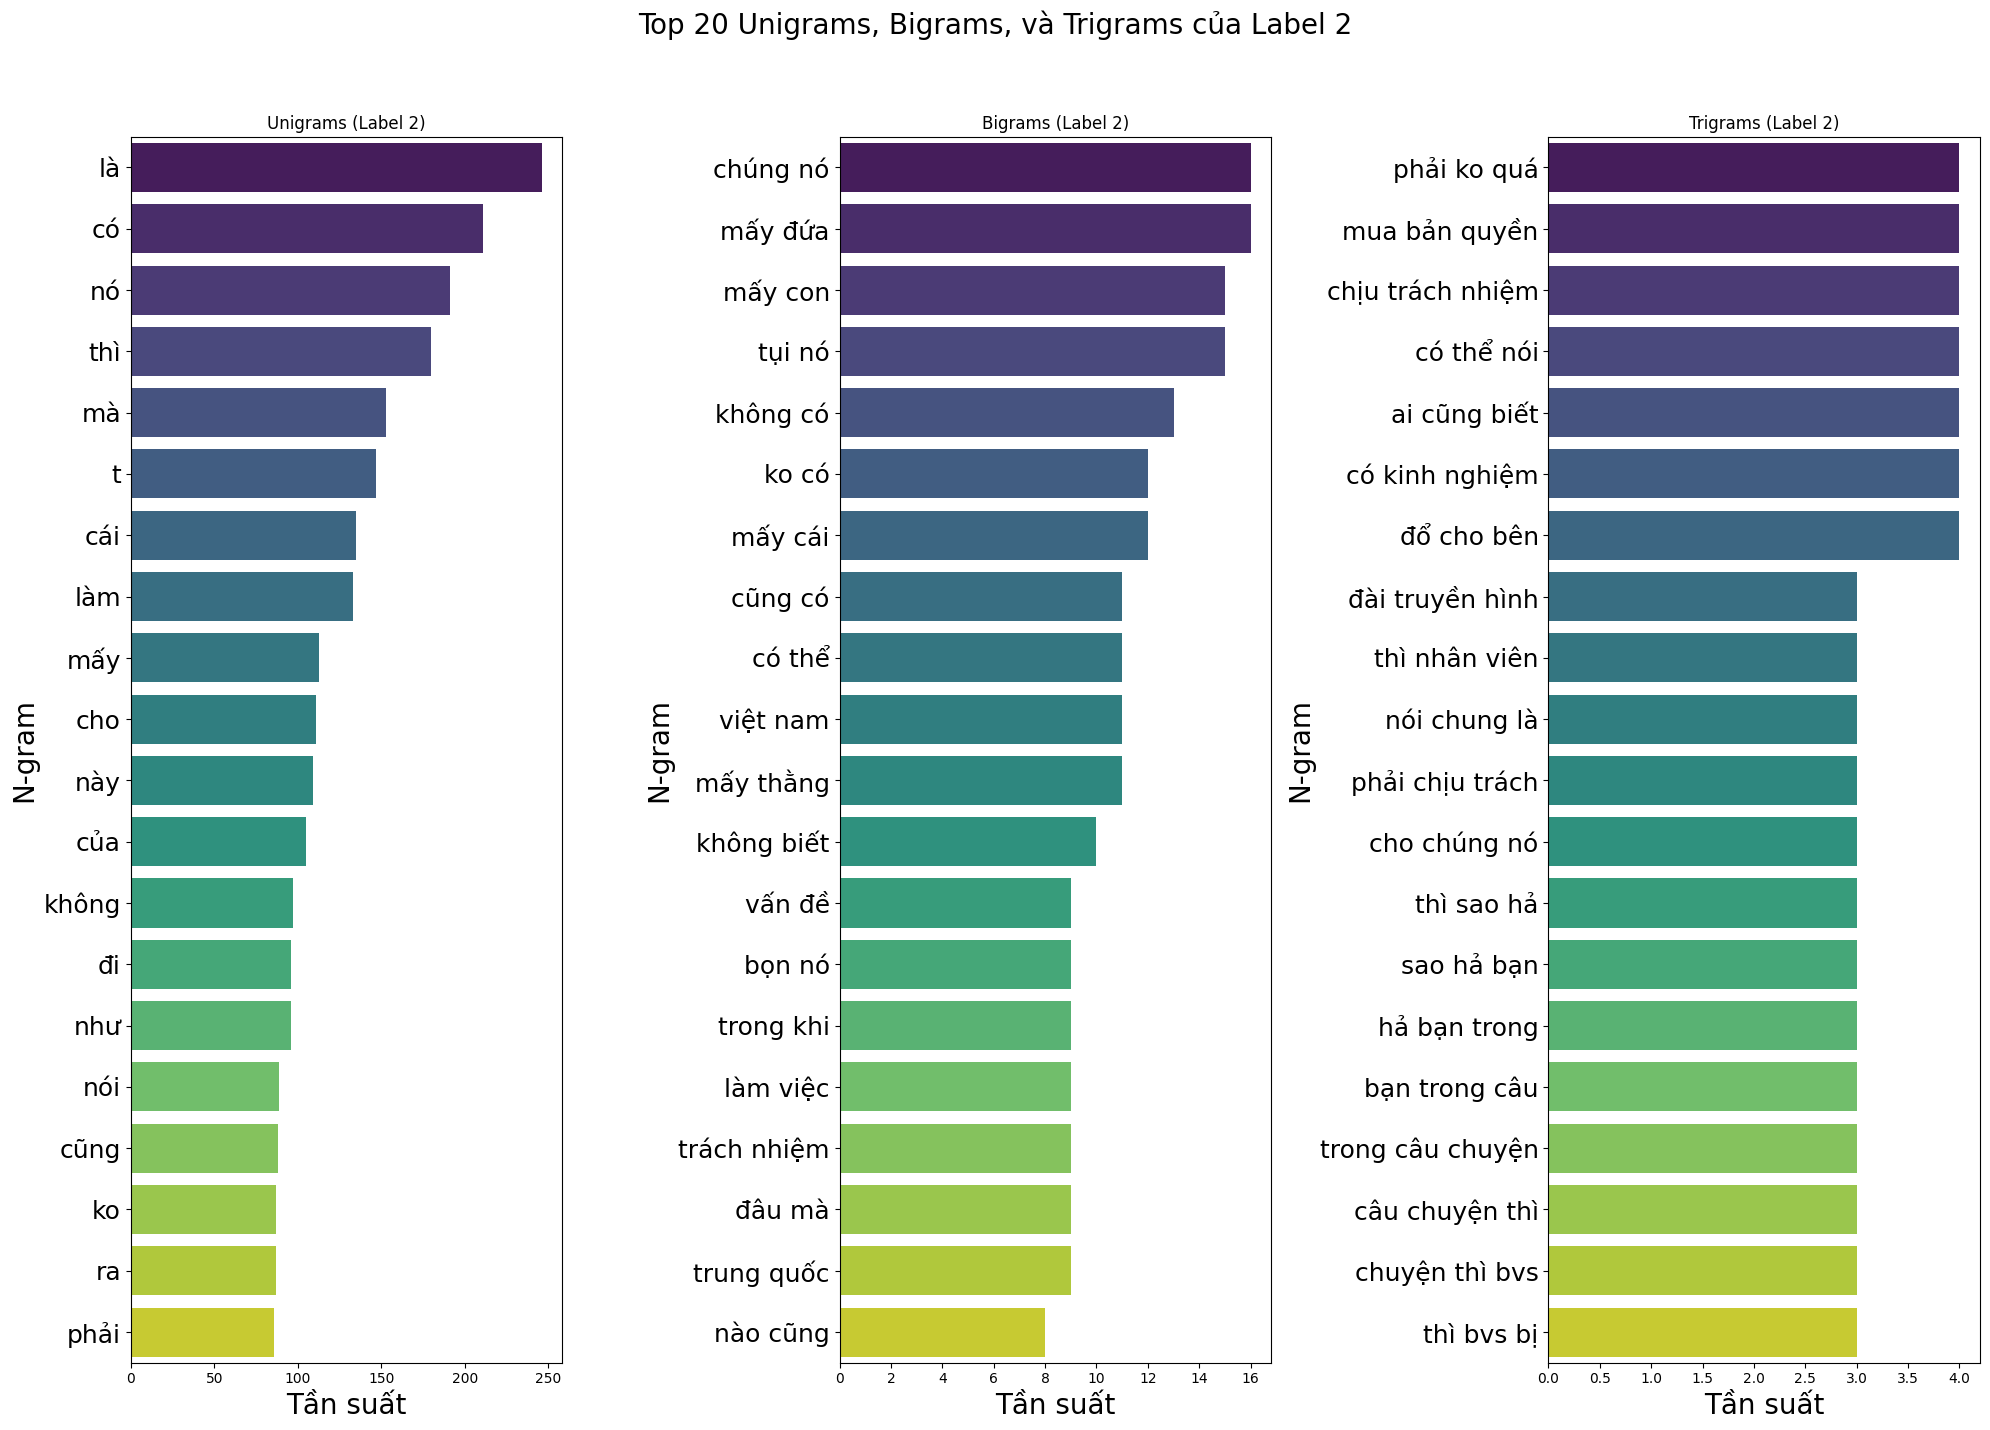

In [20]:
unique_labels = df['label'].unique()

for label_val in sorted(unique_labels):
    print(f"\n N-grams của label: {label_val}")
    label_df = df[df['label'] == label_val]
    combined_text = ' '.join(label_df['text'].astype(str))

    unigrams = get_ngrams(combined_text, 1)
    bigrams = get_ngrams(combined_text, 2)
    trigrams = get_ngrams(combined_text, 3)

    fig, axes = plt.subplots(1, 3, figsize=(20, 15))
    fig.suptitle(f'Top 20 Unigrams, Bigrams, và Trigrams của Label {label_val}', fontsize=20)

    plot_top_ngrams(unigrams, f'Unigrams (Label {label_val})', axes[0])
    plot_top_ngrams(bigrams, f'Bigrams (Label {label_val})', axes[1])
    plot_top_ngrams(trigrams, f'Trigrams (Label {label_val})', axes[2])

    # Increase the font size of the y-axis labels for all subplots
    for ax in axes:
        ax.yaxis.label.set_fontsize(20) # Set desired font size, e.g., 14
        ax.xaxis.label.set_fontsize(20)
        ax.tick_params(axis='y', labelsize=18) # Increase font size of y-axis tick values

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

- Cột label và độ dài câu

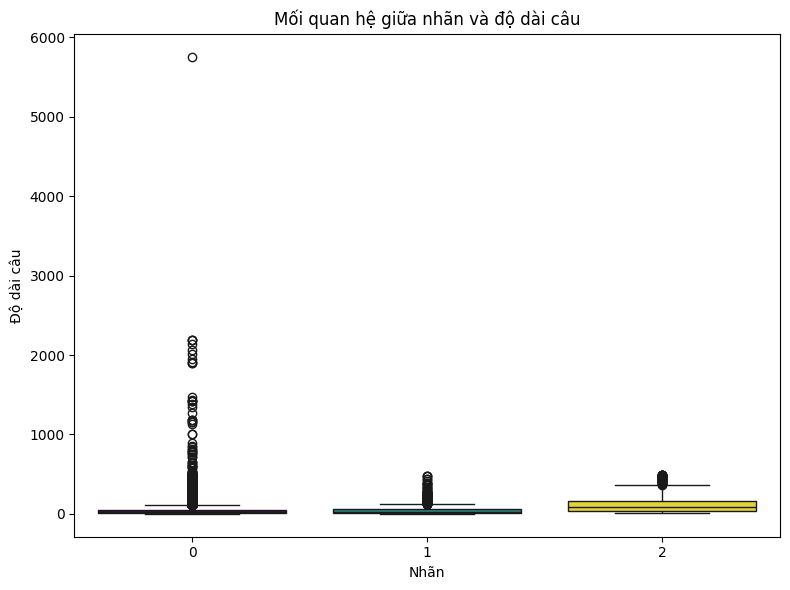

In [21]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='label', y='text_length', palette='viridis', hue='label', legend=False)
plt.title('Mối quan hệ giữa nhãn và độ dài câu')
plt.xlabel('Nhãn')
plt.ylabel('Độ dài câu')
plt.tight_layout()
plt.show()

### d. Cột source và cột topic

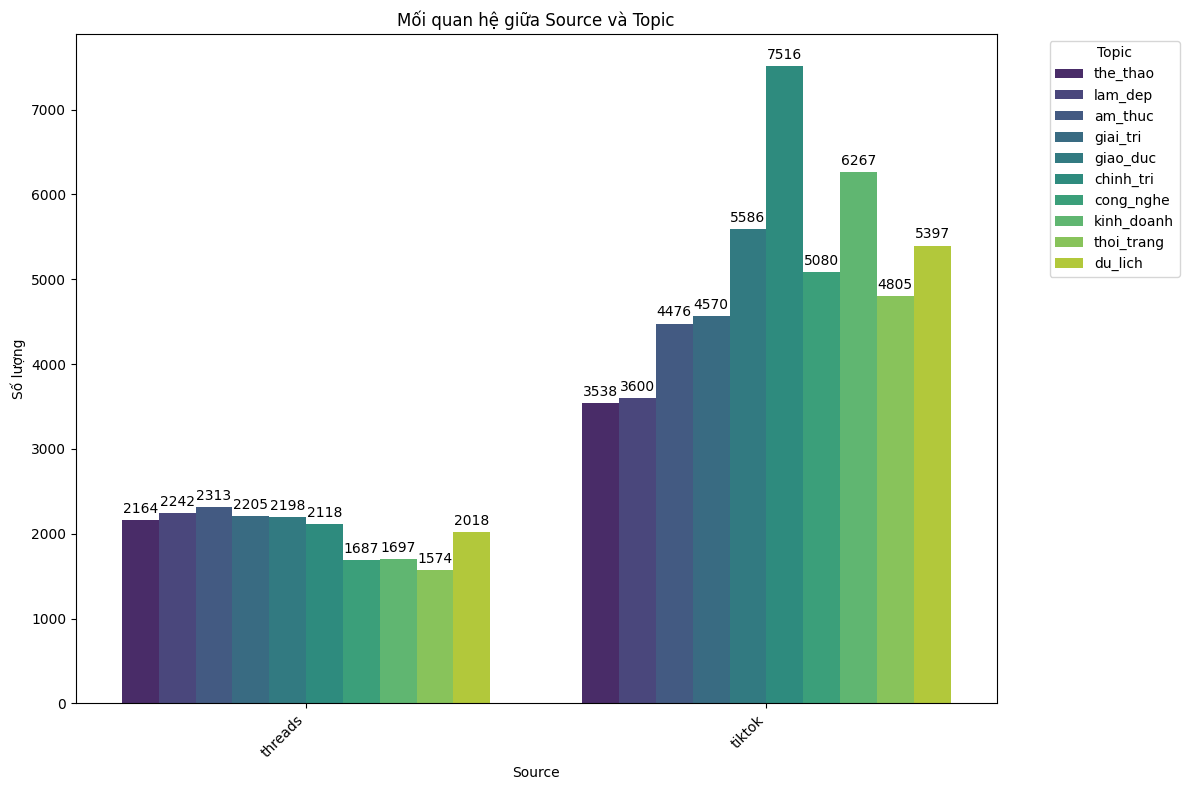

In [22]:
plt.figure(figsize=(12, 8))
ax = sns.countplot(data=df, x='source', hue='topic', palette='viridis')
plt.title('Mối quan hệ giữa Source và Topic')
plt.xlabel('Source')
plt.ylabel('Số lượng')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Topic', bbox_to_anchor=(1.05, 1), loc='upper left')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=3)

plt.tight_layout()
plt.show()

### e. Cột source và cột text

- Cột source và độ dài câu

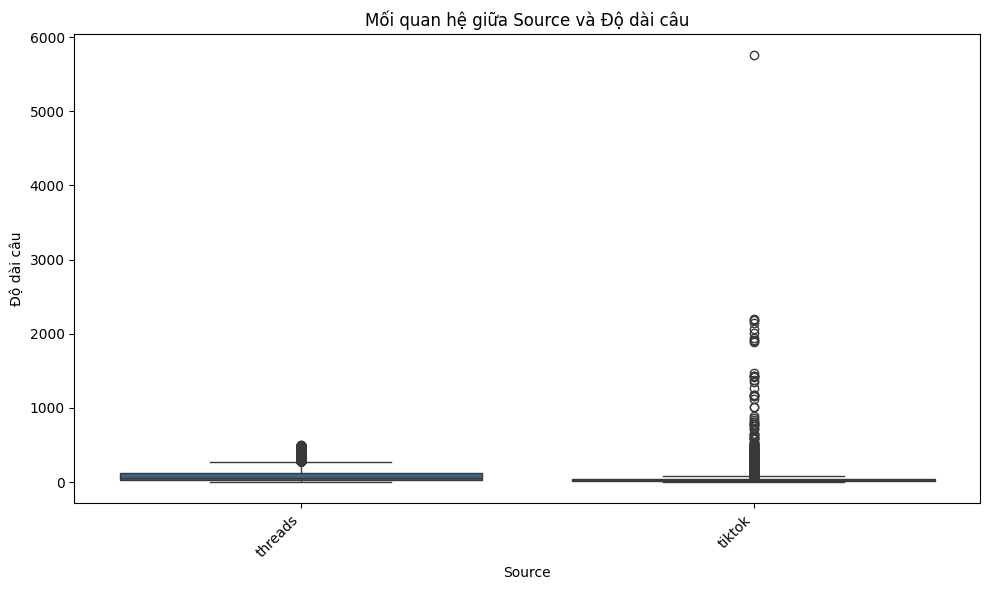

In [23]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='source', y='text_length', hue='source', palette='viridis', legend=False)
plt.title('Mối quan hệ giữa Source và Độ dài câu')
plt.xlabel('Source')
plt.ylabel('Độ dài câu')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

- Cột source và n-gram


N-grams của Source: threads


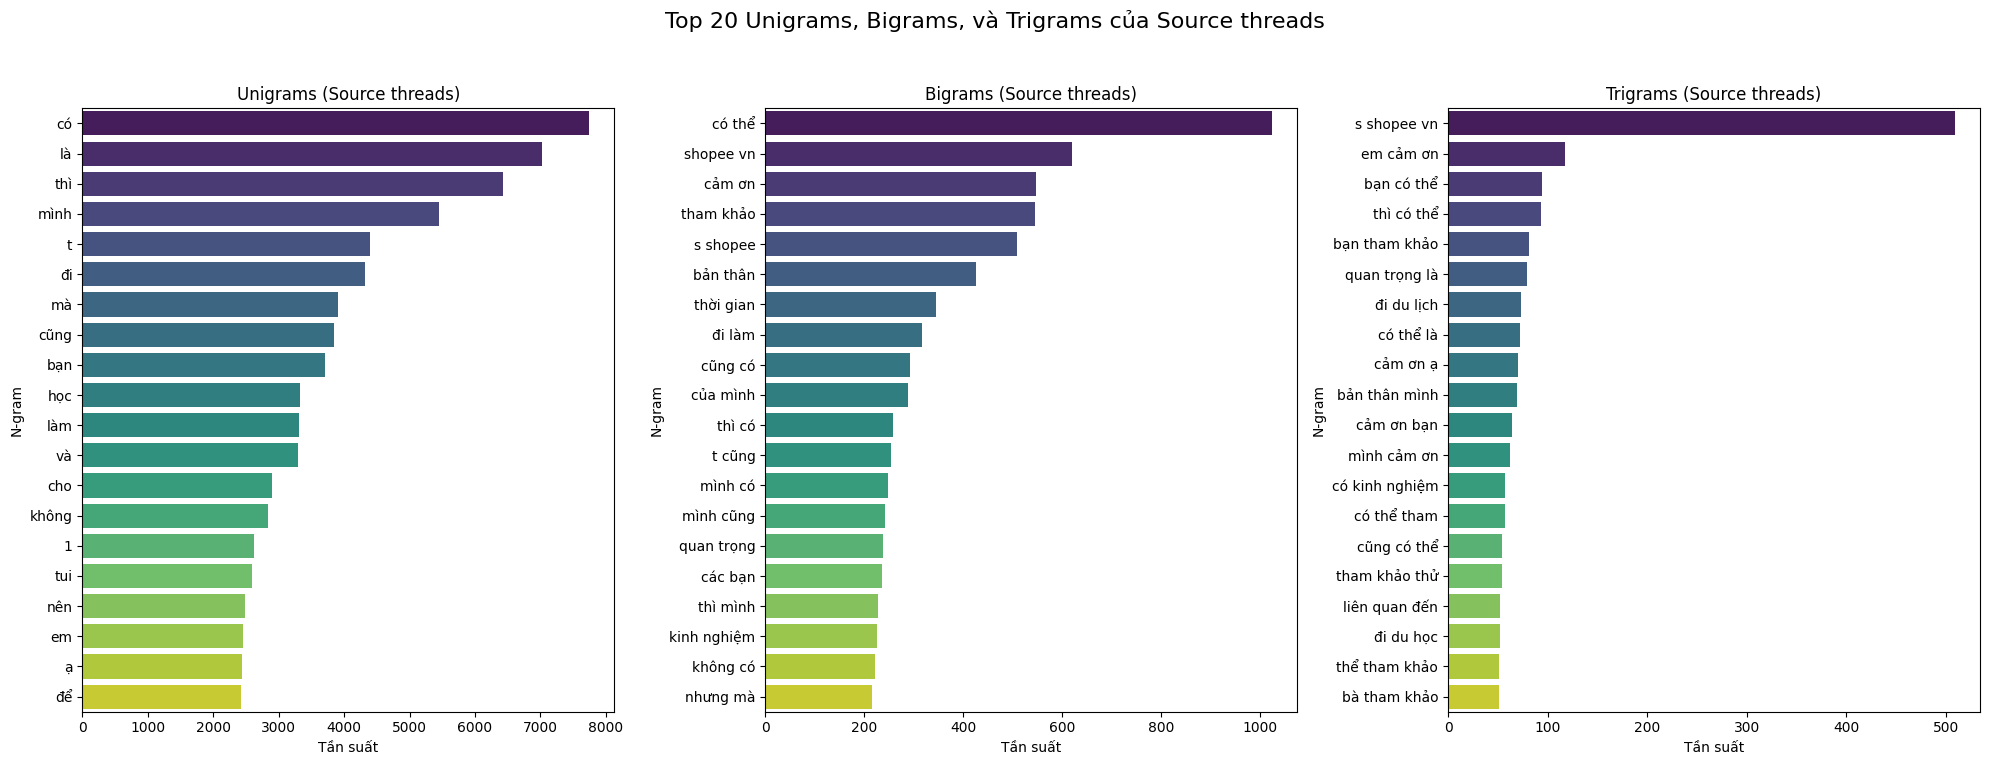


N-grams của Source: tiktok


/tmp/ipykernel_1265/3940056416.py:19: UserWarning: Glyph 4448 (\N{HANGUL JUNGSEONG FILLER}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 4448 (\N{HANGUL JUNGSEONG FILLER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


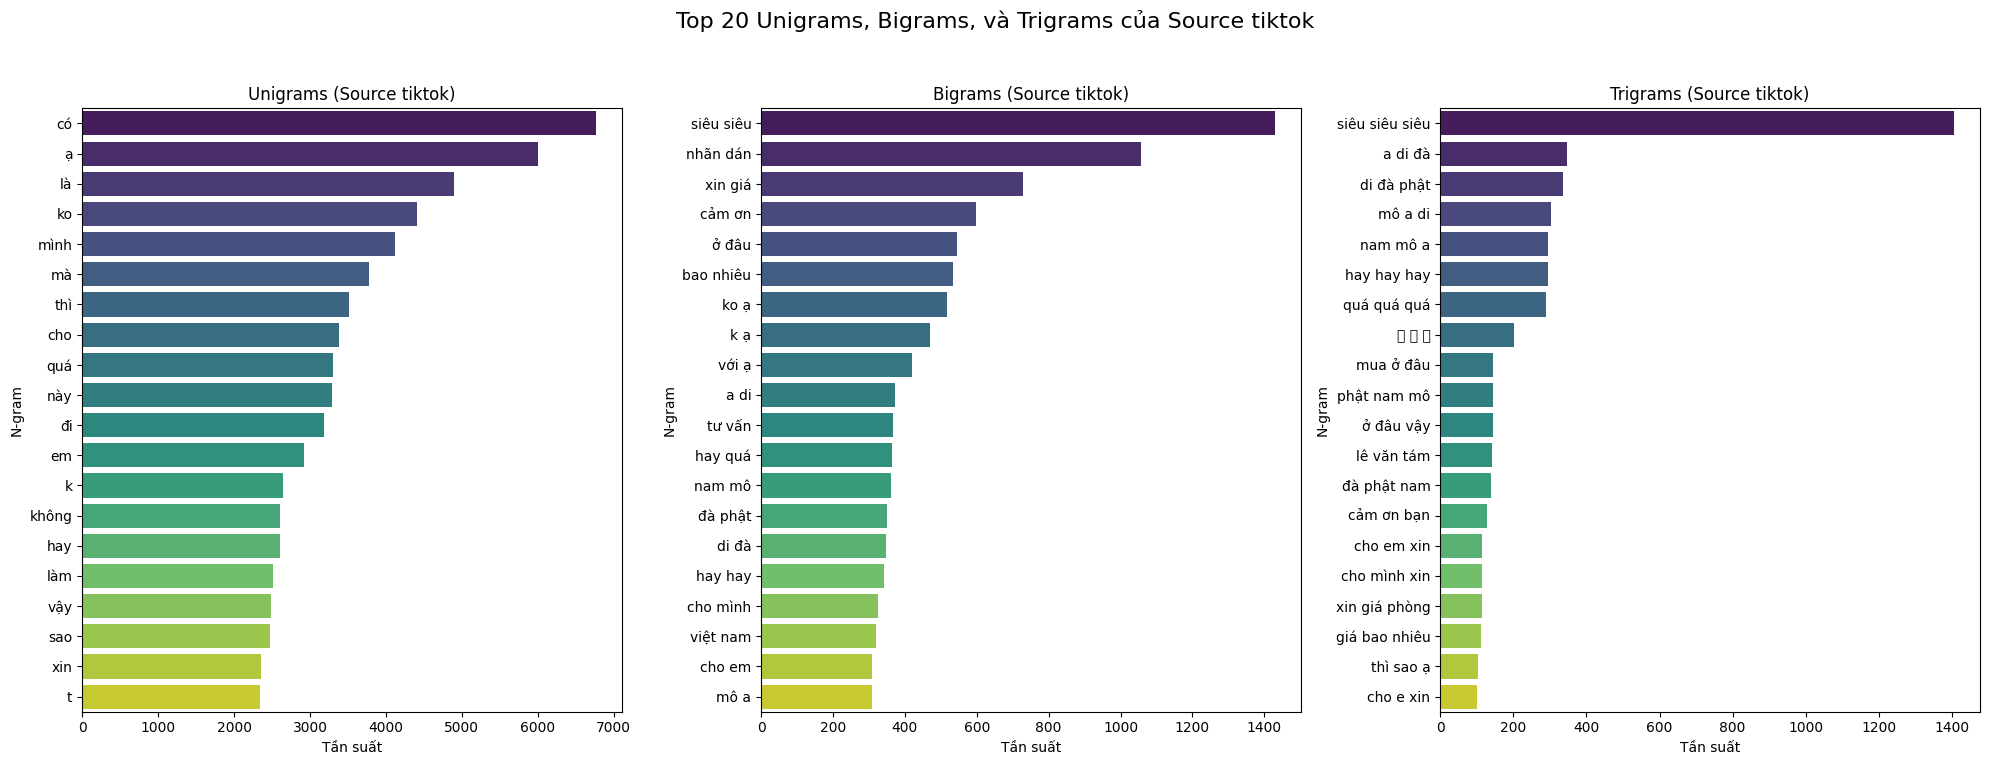

In [24]:
unique_sources = df['source'].unique()

for source_val in sorted(unique_sources):
    print(f"\nN-grams của Source: {source_val}")
    source_df = df[df['source'] == source_val]
    combined_text_source = ' '.join(source_df['text'].astype(str))

    unigrams_source = get_ngrams(combined_text_source, 1)
    bigrams_source = get_ngrams(combined_text_source, 2)
    trigrams_source = get_ngrams(combined_text_source, 3)

    fig, axes = plt.subplots(1, 3, figsize=(20, 8))
    fig.suptitle(f'Top 20 Unigrams, Bigrams, và Trigrams của Source {source_val}', fontsize=16)

    plot_top_ngrams(unigrams_source, f'Unigrams (Source {source_val})', axes[0])
    plot_top_ngrams(bigrams_source, f'Bigrams (Source {source_val})', axes[1])
    plot_top_ngrams(trigrams_source, f'Trigrams (Source {source_val})', axes[2])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# III. Phân tích dữ liệu từ 3 biến trở lên

### a. Label, source, topic

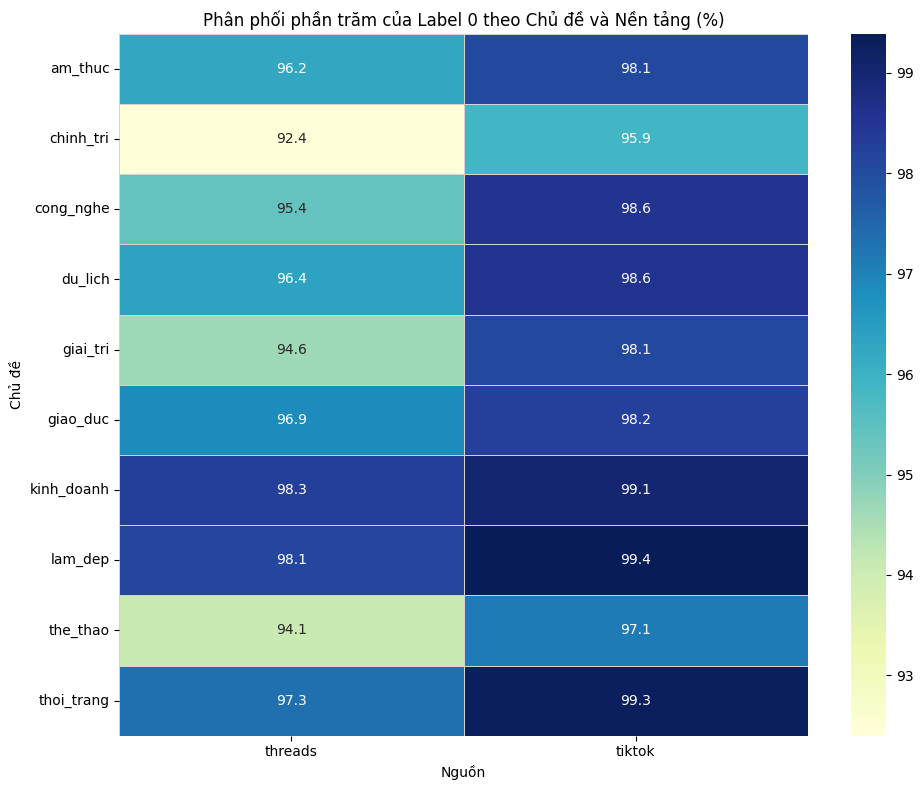

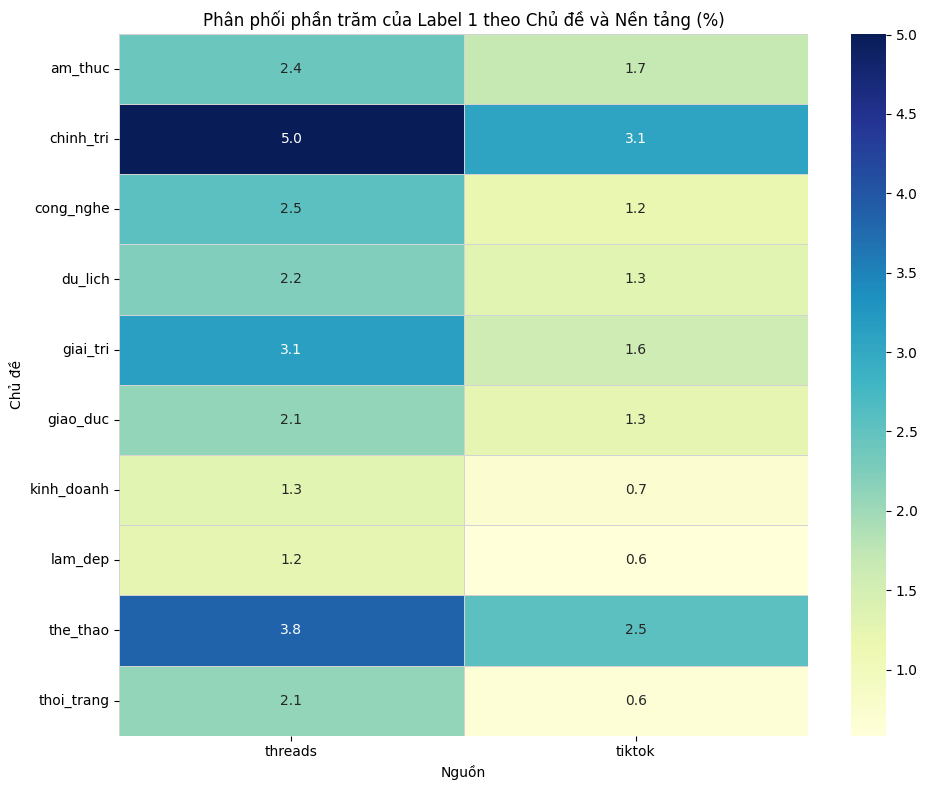

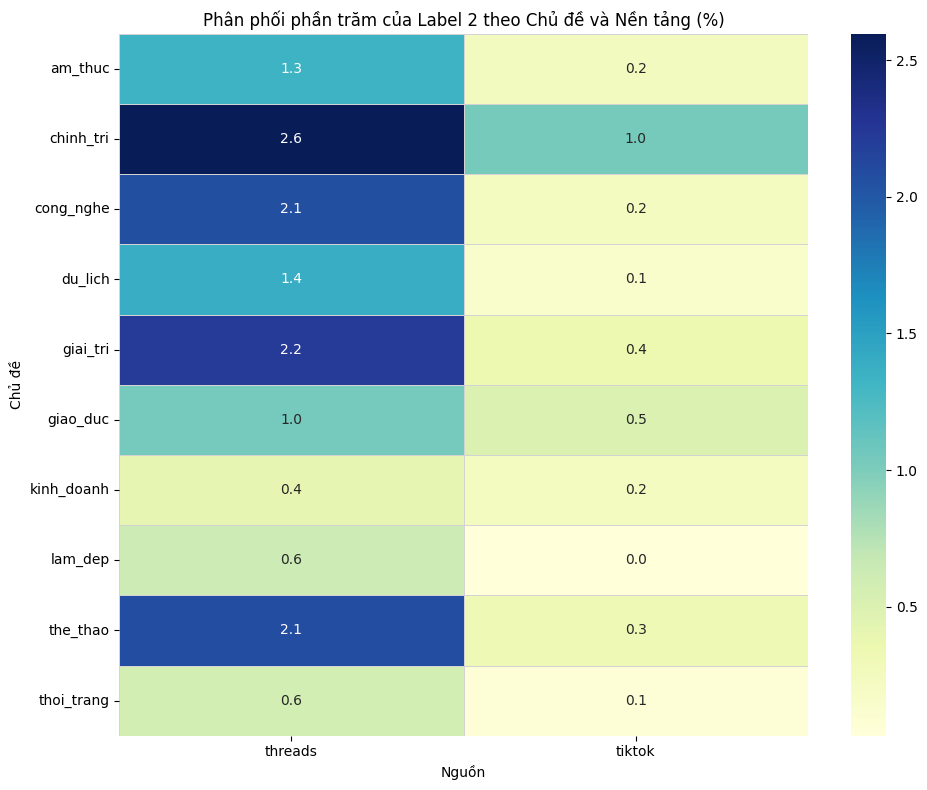

In [25]:
topic_source_label_counts = df.groupby(['topic', 'source', 'label']).size().unstack(fill_value=0)

sum_per_topic_source = topic_source_label_counts.sum(axis=1)
topic_source_label_percentages = topic_source_label_counts.div(sum_per_topic_source, axis=0) * 100
topic_source_label_percentages = topic_source_label_percentages.fillna(0)

unique_labels = sorted(df['label'].unique())

for label_val in unique_labels:
    heatmap_data_for_label = topic_source_label_percentages[[label_val]].reset_index()
    heatmap_data_for_label = heatmap_data_for_label.pivot(index='topic', columns='source', values=label_val)

    plt.figure(figsize=(10, 8))
    sns.heatmap(heatmap_data_for_label, annot=True, fmt='.1f', cmap='YlGnBu', linewidths=.5, linecolor='lightgray')
    plt.title(f'Phân phối phần trăm của Label {label_val} theo Chủ đề và Nền tảng (%)')
    plt.xlabel('Nguồn')
    plt.ylabel('Chủ đề')
    plt.tight_layout()
    plt.show()

### b. Label, source , text (độ dài)

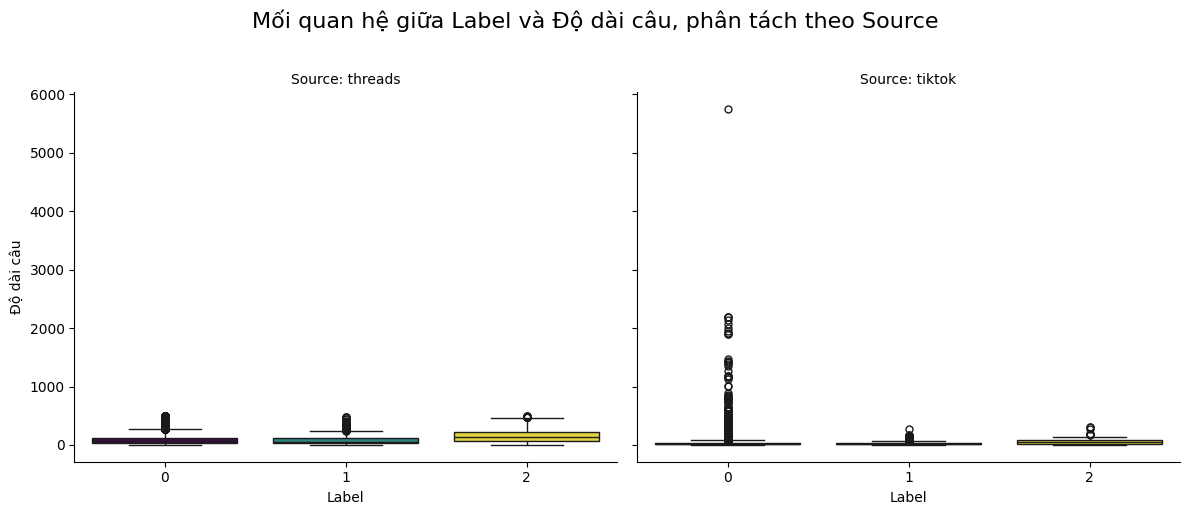

In [26]:
g = sns.catplot(data=df, x='label', y='text_length', col='source', kind='box', hue='label', palette='viridis', legend=False, height=5, aspect=1.2)
g.set_axis_labels('Label', 'Độ dài câu')
g.set_titles('Source: {col_name}')
plt.suptitle('Mối quan hệ giữa Label và Độ dài câu, phân tách theo Source', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

### c. Label , Topic , text (độ dài)

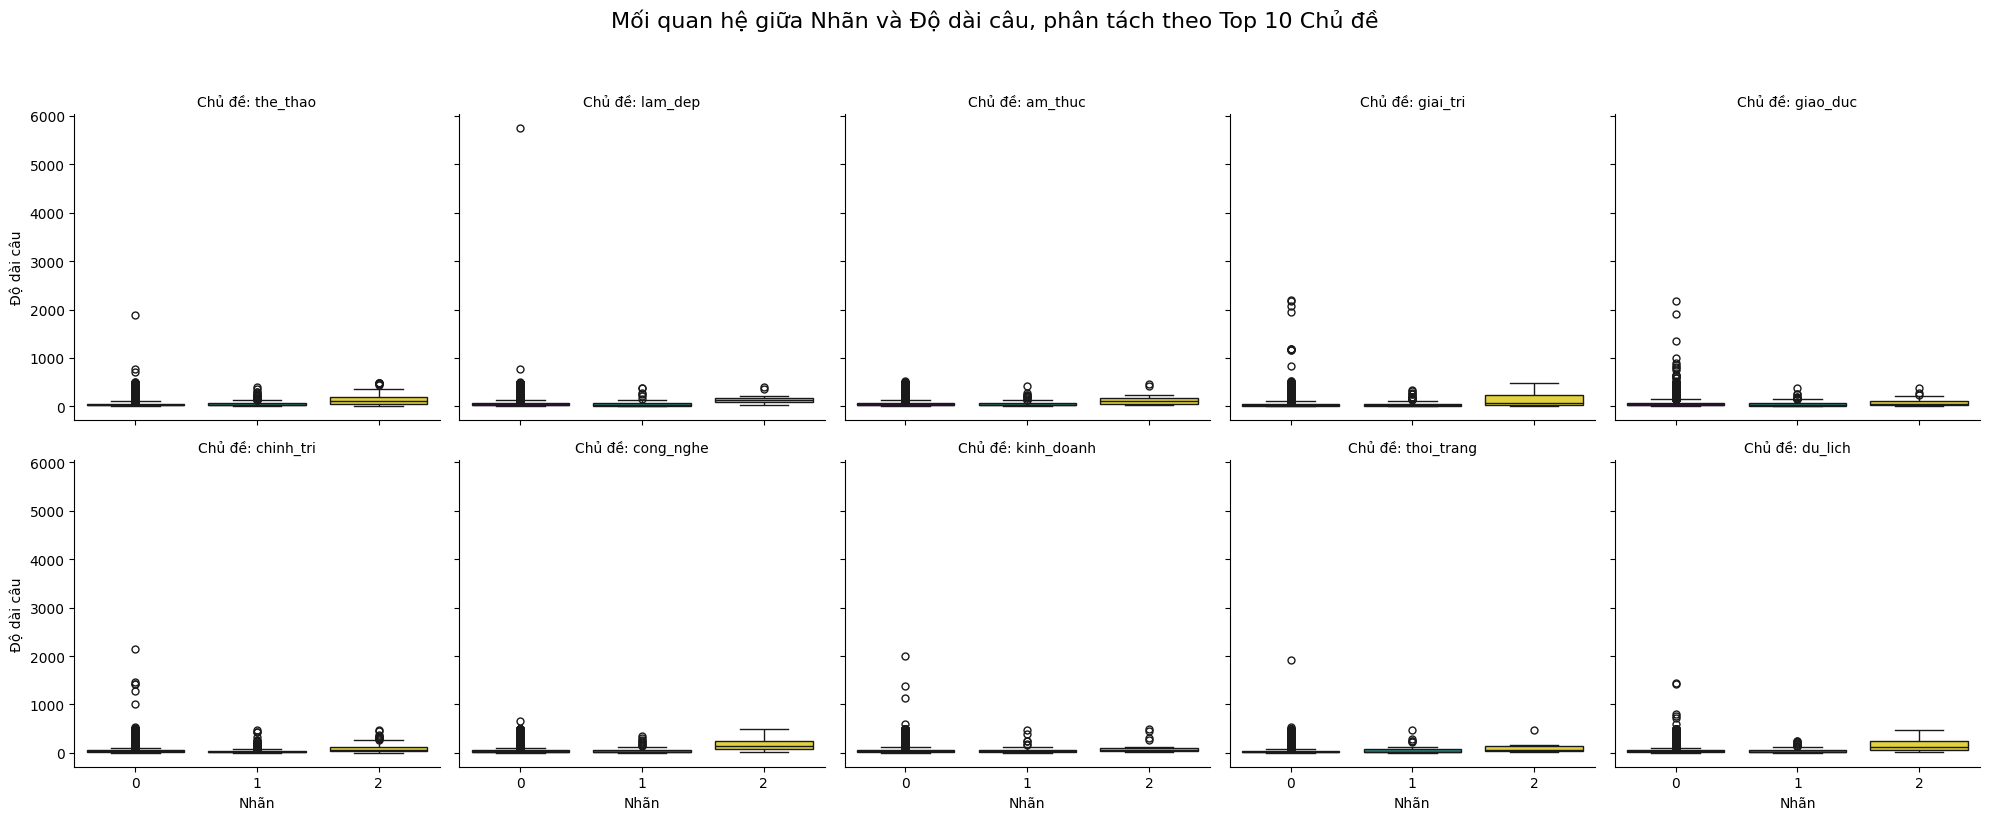

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

top_10_topics = df['topic'].value_counts().nlargest(10).index

df_top_topics = df[df['topic'].isin(top_10_topics)].copy()

g = sns.catplot(data=df_top_topics, x='label', y='text_length', col='topic',
                kind='box', col_wrap=5, height=4, aspect=1, palette='viridis',
                hue='label', legend=False, sharey=True)

g.set_axis_labels('Nhãn', 'Độ dài câu')
g.set_titles('Chủ đề: {col_name}')
plt.suptitle('Mối quan hệ giữa Nhãn và Độ dài câu, phân tách theo Top 10 Chủ đề', y=1.02, fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### d. Label, source, Topic, text (độ dài)

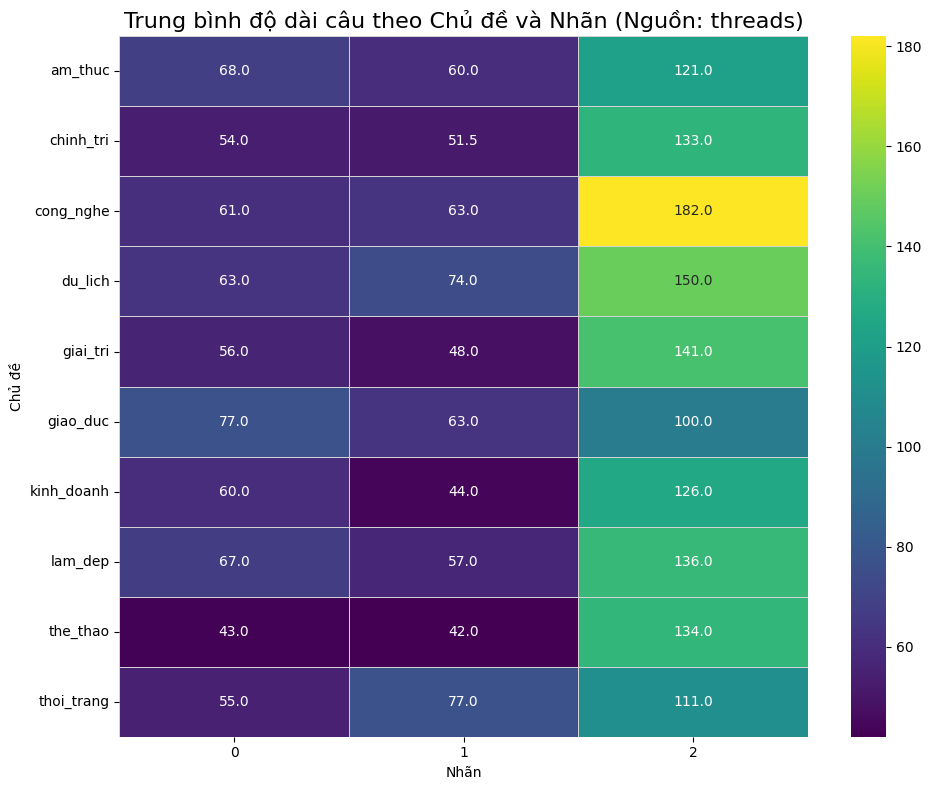

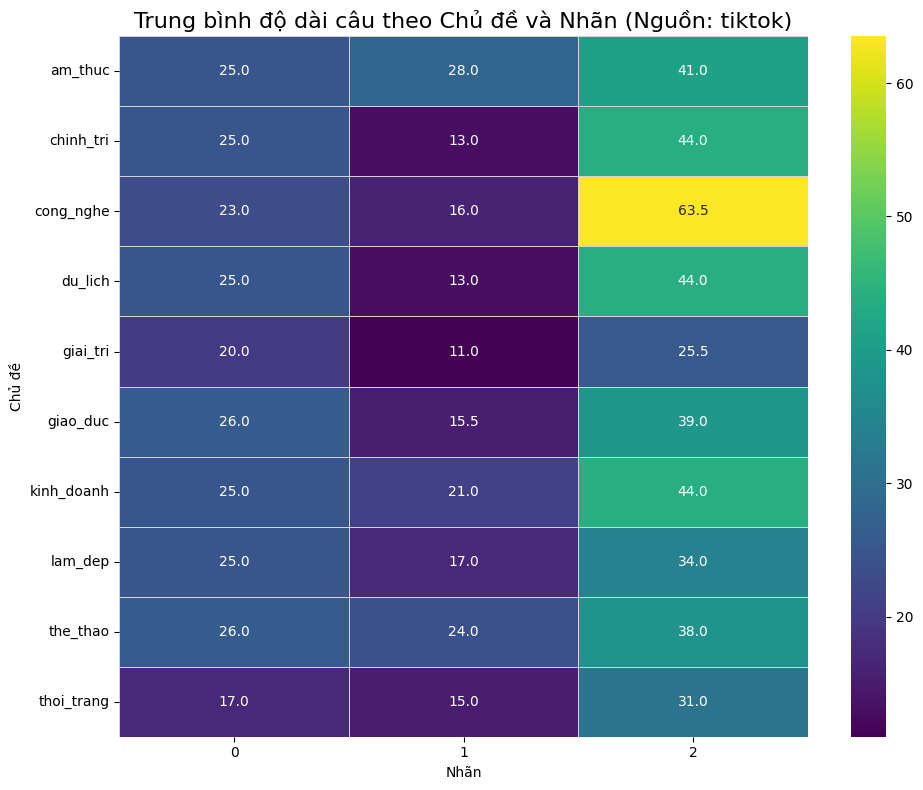

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

median_text_length_data = df.groupby(['source', 'topic', 'label'])['text_length'].median().reset_index()

unique_sources = df['source'].unique()

for source_val in unique_sources:
    data_for_source = median_text_length_data[median_text_length_data['source'] == source_val]

    heatmap_data = data_for_source.pivot(index='topic', columns='label', values='text_length')

    plt.figure(figsize=(10, 8))
    sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='viridis', linewidths=.5, linecolor='lightgray')
    plt.title(f'Trung bình độ dài câu theo Chủ đề và Nhãn (Nguồn: {source_val})', fontsize=16)
    plt.xlabel('Nhãn')
    plt.ylabel('Chủ đề')
    plt.tight_layout()
    plt.show()

### e. Label, source, text (n-gram)

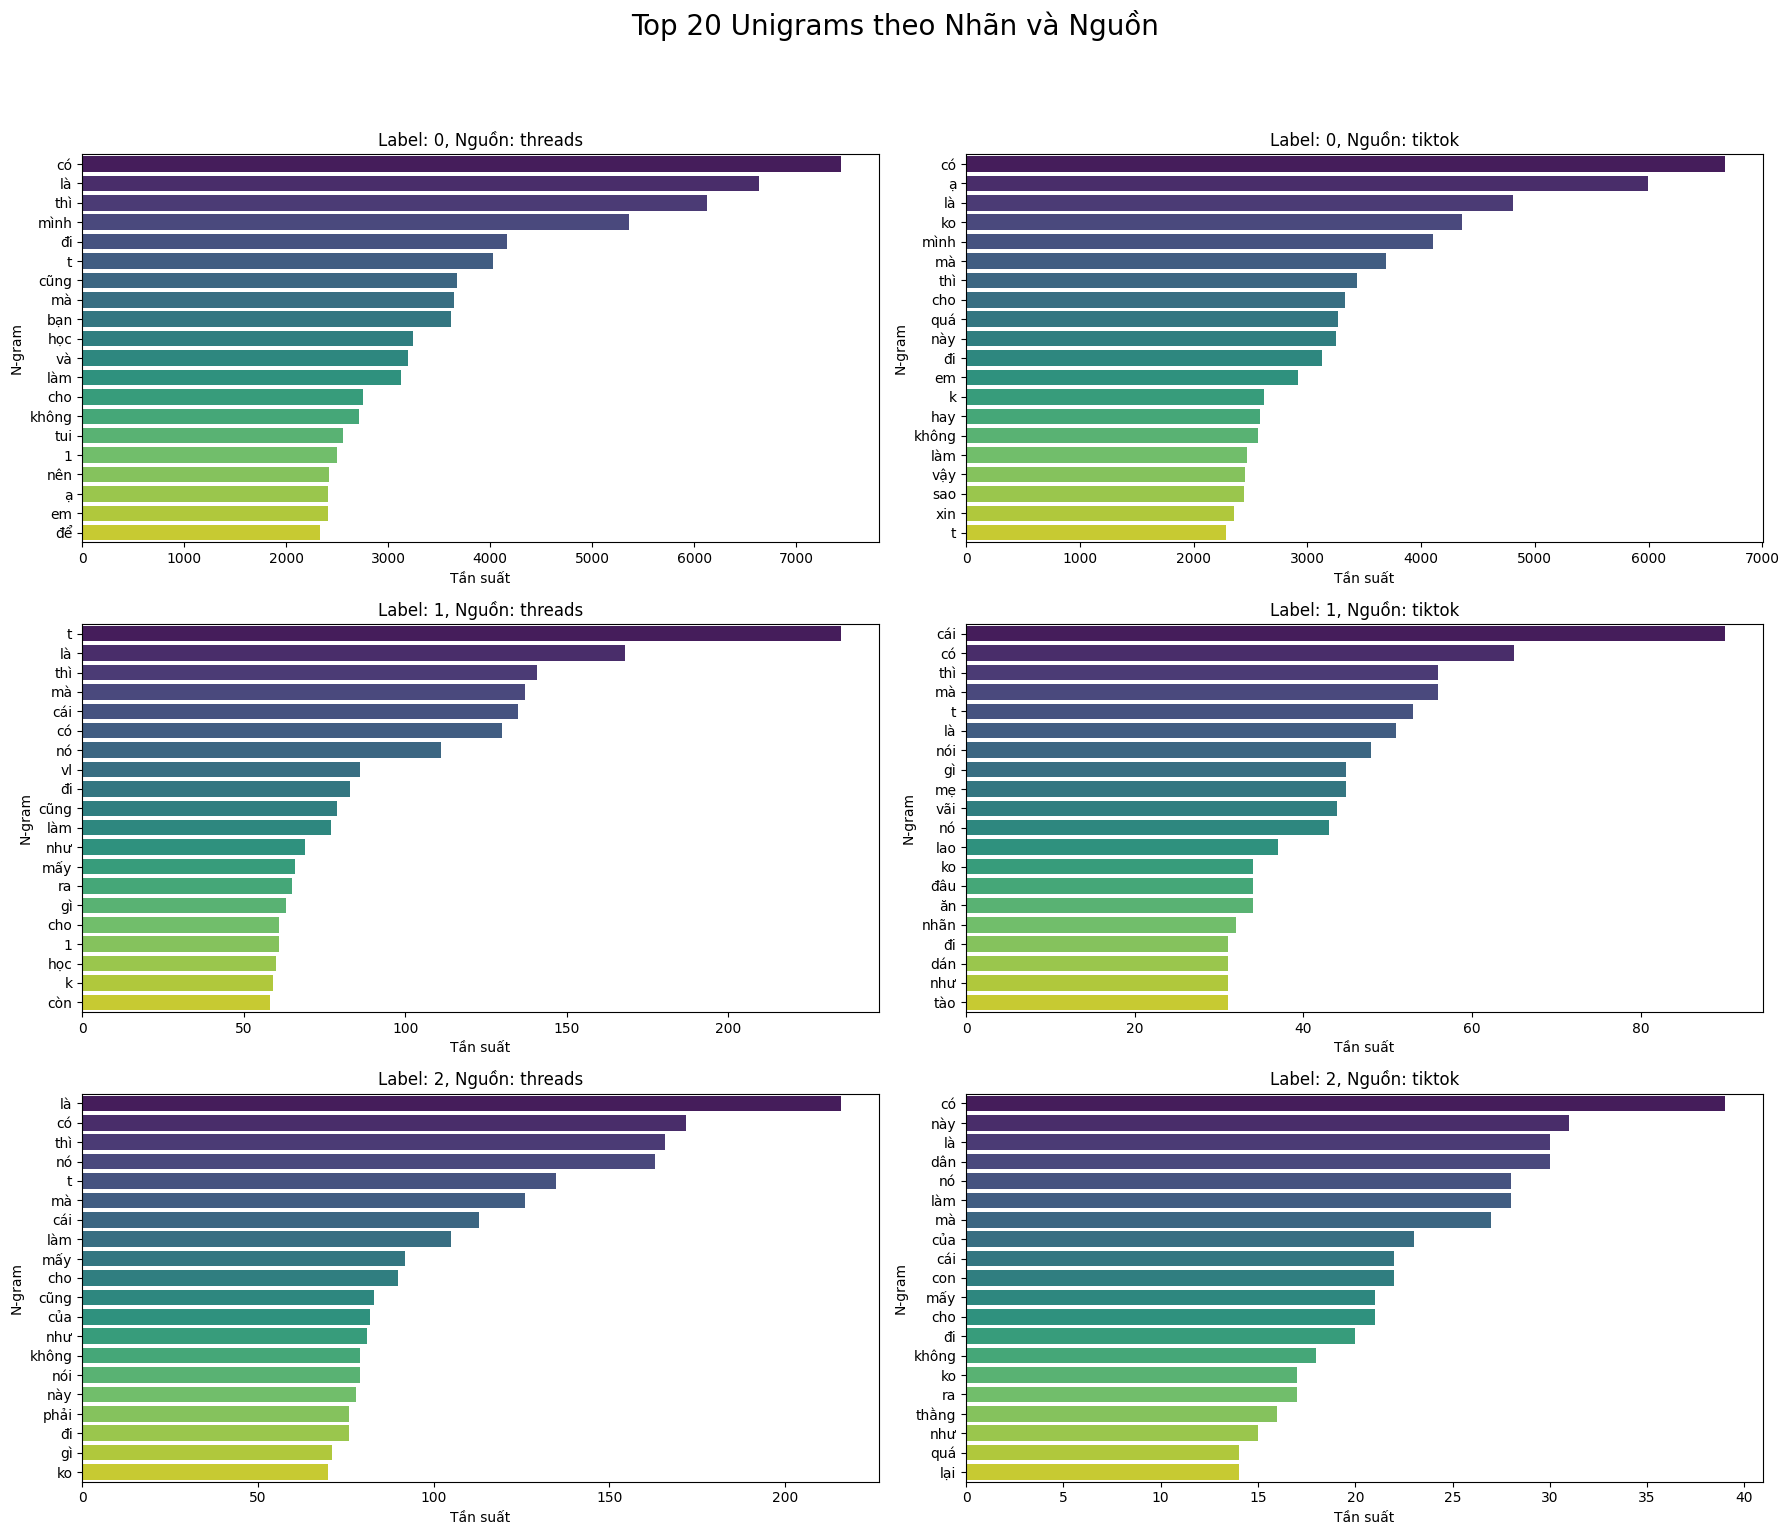

In [29]:
unique_labels = sorted(df['label'].unique())
unique_sources = sorted(df['source'].unique())

fig, axes = plt.subplots(len(unique_labels), len(unique_sources), figsize=(18, 15), sharex=False, sharey=False)
fig.suptitle('Top 20 Unigrams theo Nhãn và Nguồn', fontsize=20, y=1.02)

for i, label_val in enumerate(unique_labels):
    for j, source_val in enumerate(unique_sources):
        ax = axes[i, j]

        filtered_df = df[(df['label'] == label_val) & (df['source'] == source_val)]
        combined_text = ' '.join(filtered_df['text'].astype(str))

        unigrams = get_ngrams(combined_text, 1)

        plot_top_ngrams(unigrams, f'Label: {label_val}, Nguồn: {source_val}', ax, top_n=20)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


### f. Label, Topic, text (n-gram)

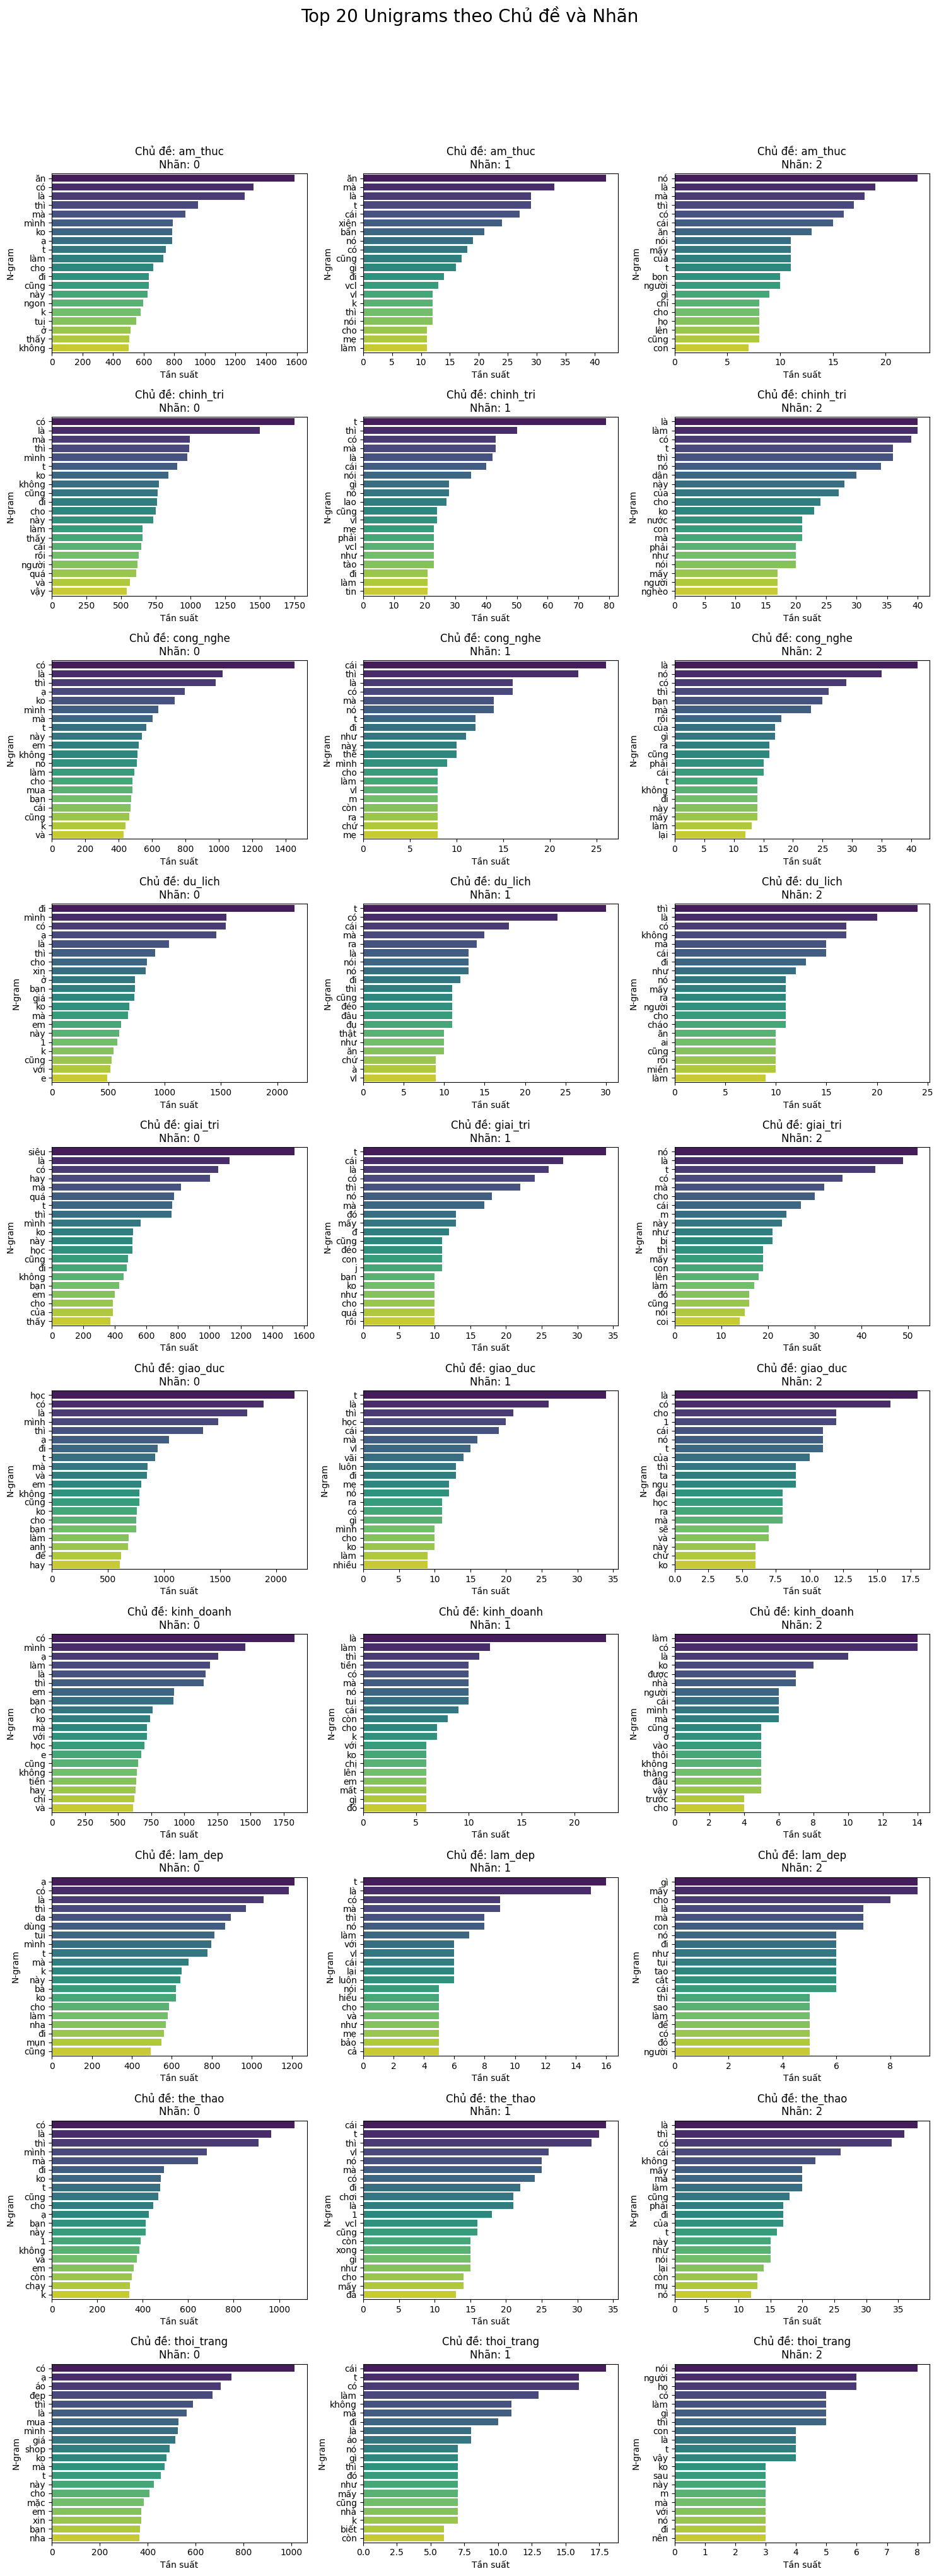

In [30]:
unique_labels = sorted(df['label'].unique())
unique_topics = sorted(df['topic'].unique())

num_labels = len(unique_labels)
num_topics = len(unique_topics)

fig, axes = plt.subplots(num_topics, num_labels, figsize=(5 * num_labels, 4 * num_topics), sharex=False, sharey=False)
fig.suptitle('Top 20 Unigrams theo Chủ đề và Nhãn', fontsize=20, y=1.02)

if num_topics == 1 and num_labels == 1:
    axes = [[axes]]
elif num_topics == 1 or num_labels == 1:
    axes = [axes]

for i, topic_val in enumerate(unique_topics):
    for j, label_val in enumerate(unique_labels):
        ax = axes[i][j]
        filtered_df = df[(df['topic'] == topic_val) & (df['label'] == label_val)]
        combined_text = ' '.join(filtered_df['text'].astype(str))

        unigrams = get_ngrams(combined_text, 1)
        plot_top_ngrams(unigrams, f'Chủ đề: {topic_val}\nNhãn: {label_val}', ax, top_n=20)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()